# ==========================================================
# Visualization and Evaluation of Synthetic Malware Samples
# Original vs SMOTE vs CTGAN
# CIC-MalMem-2022 Dataset
# ==========================================================

This notebook performs a full, end-to-end **visual and statistical evaluation** of three
versions of the CIC-MalMem-2022 memory-forensics dataset:

1. **Original** — the raw, imbalanced dataset (Benign majority; Ransomware/Spyware/Trojan minorities).
2. **SMOTE** — the dataset after minority classes are oversampled with SMOTE to match Benign.
3. **CTGAN** — the dataset after minority classes are oversampled with a CTGAN generative model to match Benign.

Every numbered section below (1-100) mirrors the requested table of contents exactly.

## 1. Project Overview

### Objective
Rigorously compare the **Original**, **SMOTE**, and **CTGAN** versions of CIC-MalMem-2022
across class balance, distributional fidelity, statistical similarity, and downstream
machine-learning utility.

### Why Compare Synthetic Data?
Oversampling techniques solve class imbalance in very different ways: SMOTE linearly
interpolates between real minority neighbors, while CTGAN learns the full joint feature
distribution and samples from it. Comparing them tells us whether the added statistical
complexity of a generative model actually buys better, more diverse, or more faithful
synthetic data than a simple, cheap interpolation method.

### Evaluation Strategy
- **Distributional**: histograms, KDEs, box/violin plots, PCA/t-SNE/UMAP embeddings.
- **Statistical**: mean/median/std/variance/skew/kurtosis, correlation structure,
  KS-test, Wasserstein distance, Jensen-Shannon distance, MMD.
- **Synthetic-sample quality**: nearest-neighbor distance, duplicate detection, novelty,
  diversity, coverage, fidelity, and overfitting checks.
- **Machine Learning Validation**: train identical classifiers on each dataset and compare
  their performance on one shared, untouched test set drawn only from real data.

### Visualization Techniques
Count/pie/bar charts, PCA, t-SNE, UMAP, histograms, KDE, box/violin/boxen plots, pair
plots, correlation heatmaps, and confusion matrices.

## 2. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import time
import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.neighbors import NearestNeighbors

from scipy import stats
from scipy.spatial.distance import cosine, euclidean, mahalanobis, jensenshannon
from scipy.stats import wasserstein_distance, ks_2samp

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("outputs", exist_ok=True)

print("Libraries imported successfully.")
print(f"UMAP available: {UMAP_AVAILABLE}")


Libraries imported successfully.
UMAP available: True


## 3. Load Datasets

### Original Dataset
### SMOTE Dataset
### CTGAN Dataset

In [2]:
UPLOAD_DIR = "/mnt/user-data/uploads"

def find_path(name):
    local = os.path.join(UPLOAD_DIR, name)
    return local if os.path.exists(local) else name

orig_raw = pd.read_csv(find_path("MalMem2022.csv"))
smote_df = pd.read_csv(find_path("MalMem2022_SMOTE.csv"))
ctgan_df = pd.read_csv(find_path("MalMem2022_CTGAN_balanced.csv"))

def collapse_category(cat):
    return "Benign" if cat == "Benign" else cat.split("-")[0]

orig_raw["Label"] = orig_raw["Category"].apply(collapse_category)
orig_raw = orig_raw.drop_duplicates().reset_index(drop=True)

non_feature_cols = ["Class", "Category", "Filename", "Label"]
feature_cols = [c for c in orig_raw.columns if c not in non_feature_cols]

orig_df = orig_raw[feature_cols + ["Label"]].copy()

print(f"Original dataset : {orig_df.shape}")
print(f"SMOTE dataset    : {smote_df.shape}")
print(f"CTGAN dataset    : {ctgan_df.shape}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")


Original dataset : (58062, 56)
SMOTE dataset    : (117192, 56)
CTGAN dataset    : (116924, 56)
Feature columns (55): ['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.no

## 4. Dataset Overview

### Shape
### Number of Features
### Number of Classes

In [3]:
overview = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "CTGAN"],
    "Rows": [orig_df.shape[0], smote_df.shape[0], ctgan_df.shape[0]],
    "Columns": [orig_df.shape[1], smote_df.shape[1], ctgan_df.shape[1]],
    "Features": [len(feature_cols)] * 3,
    "Classes": [orig_df["Label"].nunique(), smote_df["Label"].nunique(), ctgan_df["Label"].nunique()],
})
overview


,Dataset,Rows,Columns,Features,Classes
0,Original,58062,56,55,4
1,SMOTE,117192,56,55,4
2,CTGAN,116924,56,55,4


## 5. Verify Dataset Integrity

### Missing Values
### Duplicate Values
### Data Types

In [4]:
integrity = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "CTGAN"],
    "Missing Values": [orig_df.isnull().sum().sum(), smote_df.isnull().sum().sum(), ctgan_df.isnull().sum().sum()],
    "Duplicate Rows": [orig_df.duplicated().sum(), smote_df.duplicated().sum(), ctgan_df.duplicated().sum()],
})
integrity


,Dataset,Missing Values,Duplicate Rows
0,Original,0,25
1,SMOTE,0,1113
2,CTGAN,0,25


In [5]:
dtype_summary = pd.DataFrame({
    "Original": orig_df[feature_cols].dtypes.value_counts(),
    "SMOTE": smote_df[feature_cols].dtypes.value_counts(),
    "CTGAN": ctgan_df[feature_cols].dtypes.value_counts(),
}).fillna(0).astype(int)
dtype_summary


,Original,SMOTE,CTGAN
int64,40,40,40
float64,15,15,15


## 6. Compare Dataset Statistics

### Samples
### Features
### Class Distribution

In [6]:
orig_counts = orig_df["Label"].value_counts()
smote_counts = smote_df["Label"].value_counts()
ctgan_counts = ctgan_df["Label"].value_counts()

stats_summary = pd.DataFrame({
    "Original": orig_counts,
    "SMOTE": smote_counts,
    "CTGAN": ctgan_counts,
})
stats_summary


,Original,SMOTE,CTGAN
Label,,,
Benign,29231,29298,29231
Ransomware,9529,29298,29231
Spyware,9815,29298,29231
Trojan,9487,29298,29231


# ==========================================================
# Class Distribution Comparison
# ==========================================================

## 7. Original Dataset Distribution

In [7]:
print(orig_counts)
print(f"Imbalance ratio (min/max): {orig_counts.min()/orig_counts.max():.3f}")


Label
Benign        29231
Spyware        9815
Ransomware     9529
Trojan         9487
Name: count, dtype: int64
Imbalance ratio (min/max): 0.325


## 8. SMOTE Dataset Distribution

In [8]:
print(smote_counts)
print(f"Imbalance ratio (min/max): {smote_counts.min()/smote_counts.max():.3f}")


Label
Benign        29298
Ransomware    29298
Spyware       29298
Trojan        29298
Name: count, dtype: int64
Imbalance ratio (min/max): 1.000


## 9. CTGAN Dataset Distribution

In [9]:
print(ctgan_counts)
print(f"Imbalance ratio (min/max): {ctgan_counts.min()/ctgan_counts.max():.3f}")


Label
Benign        29231
Ransomware    29231
Spyware       29231
Trojan        29231
Name: count, dtype: int64
Imbalance ratio (min/max): 1.000


## 10. Count Plot Comparison

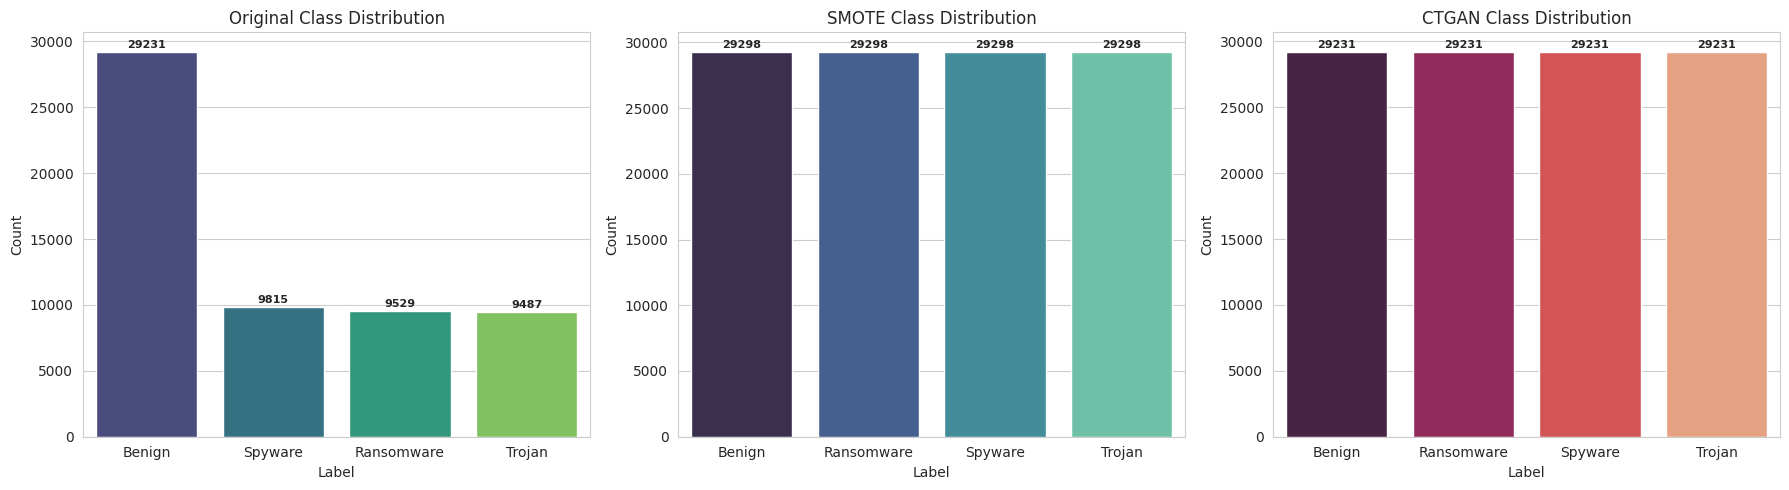

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, counts, title, pal in zip(
    axes, [orig_counts, smote_counts, ctgan_counts],
    ["Original", "SMOTE", "CTGAN"], ["viridis", "mako", "rocket"]
):
    sns.barplot(x=counts.index, y=counts.values, palette=pal, ax=ax)
    ax.set_title(f"{title} Class Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 300, str(v), ha="center", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.show()


## 11. Pie Chart Comparison

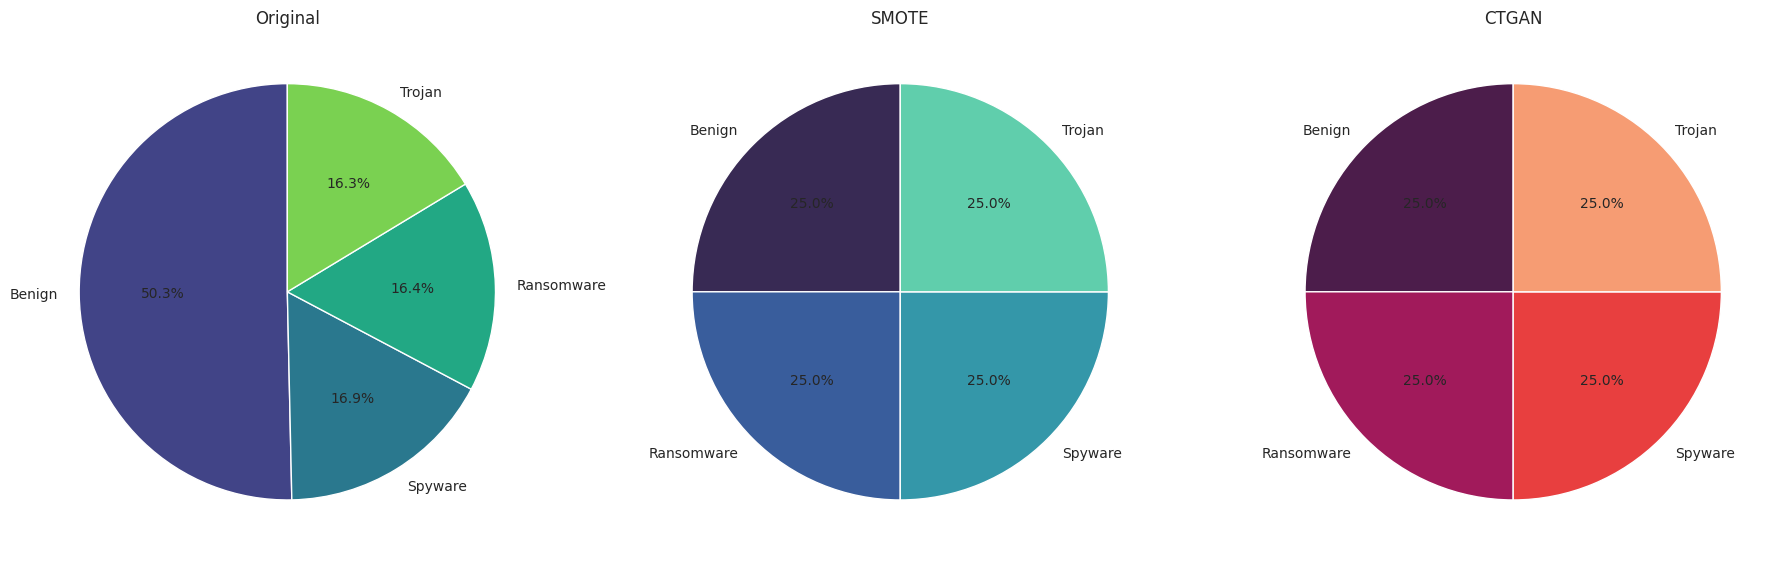

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, counts, title, pal in zip(
    axes, [orig_counts, smote_counts, ctgan_counts],
    ["Original", "SMOTE", "CTGAN"], ["viridis", "mako", "rocket"]
):
    ax.pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
           colors=sns.color_palette(pal, len(counts)))
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 12. Bar Chart Comparison

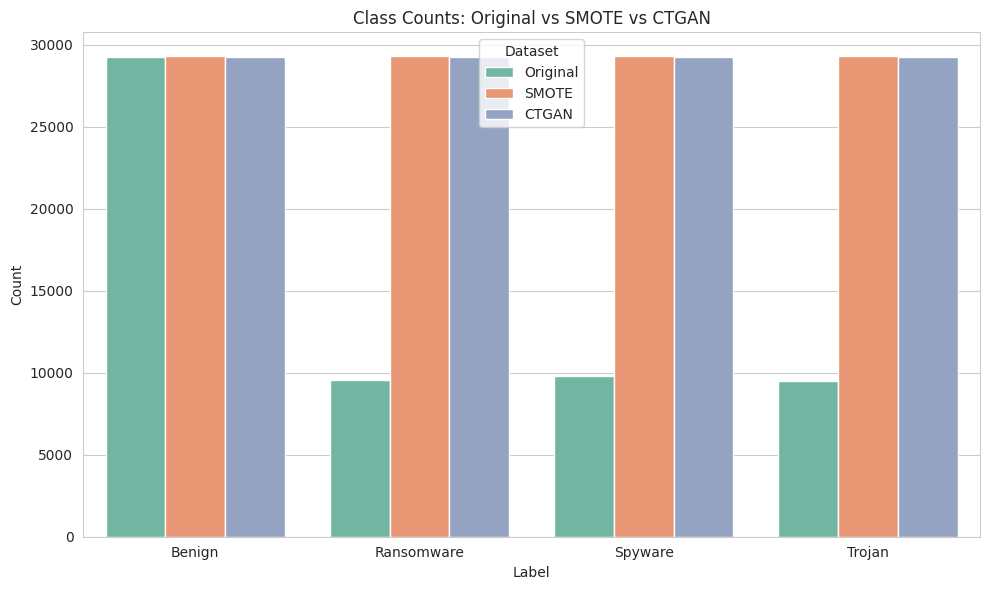

In [12]:
bar_df = stats_summary.reset_index().melt(id_vars="Label", var_name="Dataset", value_name="Count")
plt.figure(figsize=(10, 6))
sns.barplot(data=bar_df, x="Label", y="Count", hue="Dataset", palette="Set2")
plt.title("Class Counts: Original vs SMOTE vs CTGAN")
plt.tight_layout()
plt.show()


## 13. Class Percentage Comparison

In [13]:
pct_summary = (stats_summary / stats_summary.sum() * 100).round(2)
pct_summary


,Original,SMOTE,CTGAN
Label,,,
Benign,50.34,25.0,25.0
Ransomware,16.41,25.0,25.0
Spyware,16.90,25.0,25.0
Trojan,16.34,25.0,25.0


# ==========================================================
# PCA Visualization
# ==========================================================

## 14. Introduction to PCA

**Principal Component Analysis (PCA)** finds the orthogonal directions of maximum variance
in the data and projects it onto a lower-dimensional space. Here we use it to compress the
54-dimensional feature space into 2 dimensions for visual comparison of how each dataset's
samples are distributed.

## 15. Standardize Features

In [14]:
SAMPLE_SIZE = 3000

def stratified_sample(df, label_col, n, seed=RANDOM_STATE):
    n_per_class = max(1, n // df[label_col].nunique())
    return (
        df.groupby(label_col, group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), n_per_class), random_state=seed))
        .reset_index(drop=True)
    )

orig_sample = stratified_sample(orig_df, "Label", SAMPLE_SIZE)
smote_sample = stratified_sample(smote_df, "Label", SAMPLE_SIZE)
ctgan_sample = stratified_sample(ctgan_df, "Label", SAMPLE_SIZE)

pca_scaler = StandardScaler().fit(orig_df[feature_cols])

orig_scaled = pca_scaler.transform(orig_sample[feature_cols])
smote_scaled = pca_scaler.transform(smote_sample[feature_cols])
ctgan_scaled = pca_scaler.transform(ctgan_sample[feature_cols])

print("Standardized sample shapes:", orig_scaled.shape, smote_scaled.shape, ctgan_scaled.shape)


Standardized sample shapes: (3000, 55) (3000, 55) (3000, 55)


## 16. Apply PCA (2 Components)

In [15]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d.fit(pca_scaler.transform(orig_df[feature_cols].sample(min(10000, len(orig_df)), random_state=RANDOM_STATE)))

orig_pca = pca_2d.transform(orig_scaled)
smote_pca = pca_2d.transform(smote_scaled)
ctgan_pca = pca_2d.transform(ctgan_scaled)

print("PCA projections computed for all three datasets.")


PCA projections computed for all three datasets.


## 17. PCA on Original Dataset

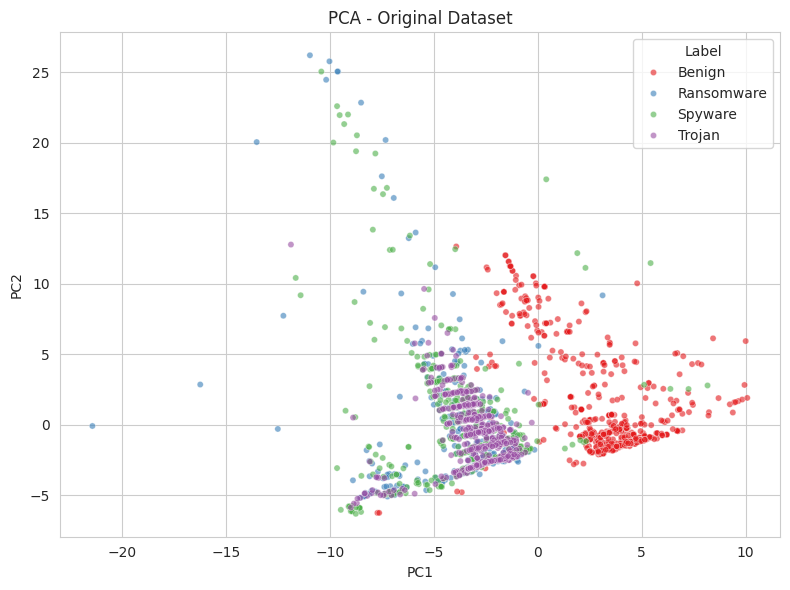

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=orig_pca[:, 0], y=orig_pca[:, 1], hue=orig_sample["Label"], palette="Set1", alpha=0.6, s=20)
plt.title("PCA - Original Dataset")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 18. PCA on SMOTE Dataset

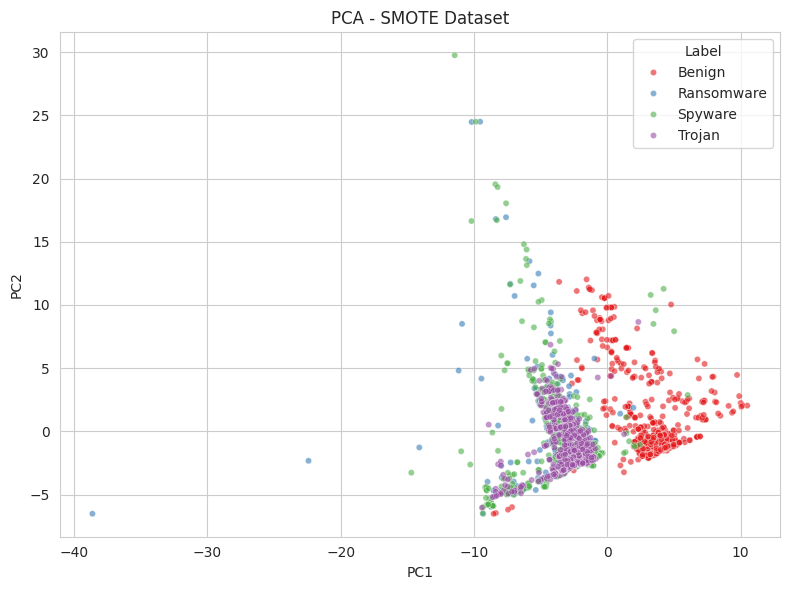

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=smote_pca[:, 0], y=smote_pca[:, 1], hue=smote_sample["Label"], palette="Set1", alpha=0.6, s=20)
plt.title("PCA - SMOTE Dataset")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 19. PCA on CTGAN Dataset

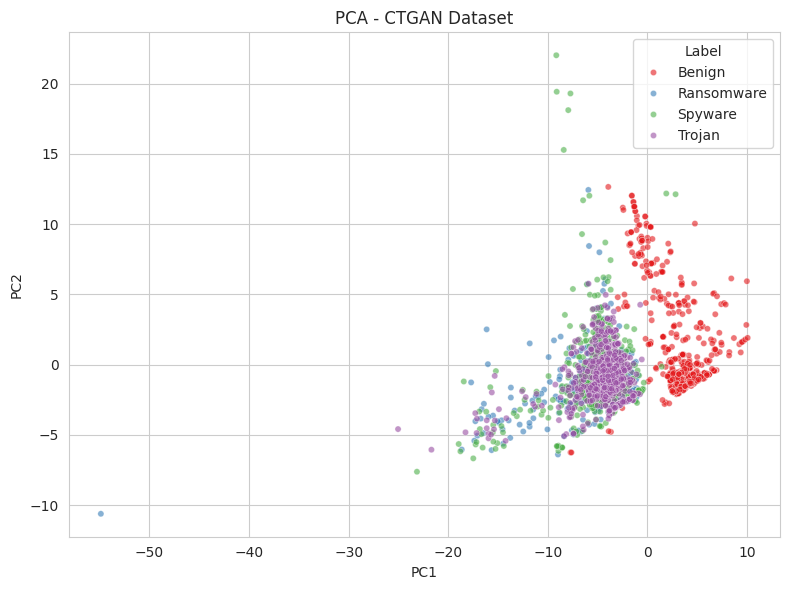

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=ctgan_pca[:, 0], y=ctgan_pca[:, 1], hue=ctgan_sample["Label"], palette="Set1", alpha=0.6, s=20)
plt.title("PCA - CTGAN Dataset")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 20. Overlay Original vs SMOTE

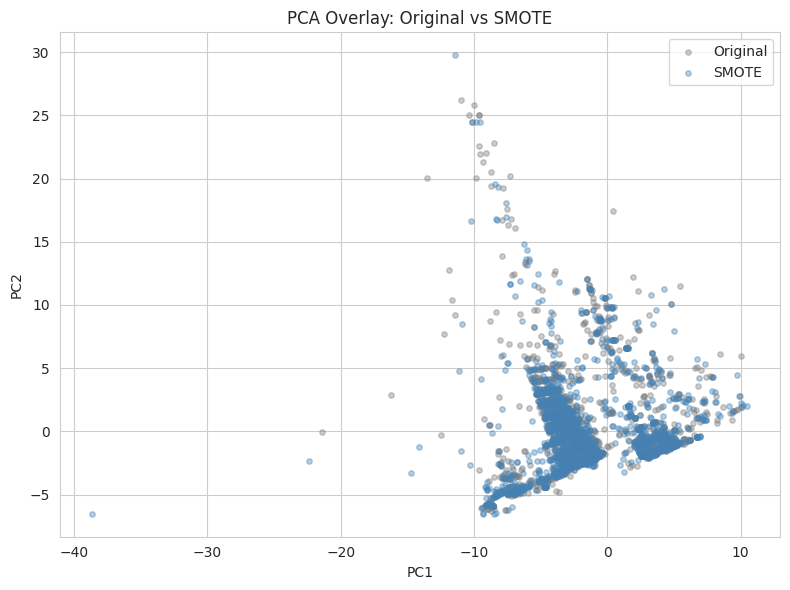

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(orig_pca[:, 0], orig_pca[:, 1], alpha=0.4, s=15, label="Original", color="gray")
plt.scatter(smote_pca[:, 0], smote_pca[:, 1], alpha=0.4, s=15, label="SMOTE", color="steelblue")
plt.title("PCA Overlay: Original vs SMOTE")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout()
plt.show()


## 21. Overlay Original vs CTGAN

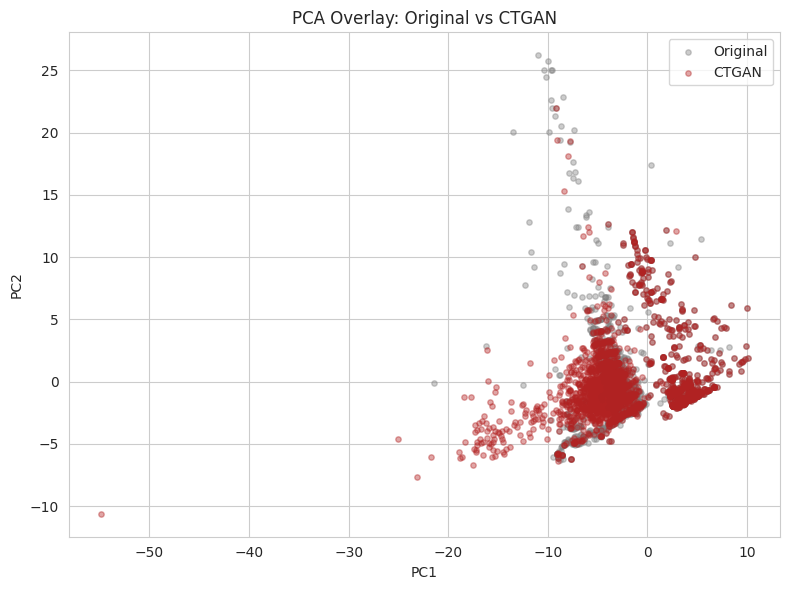

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(orig_pca[:, 0], orig_pca[:, 1], alpha=0.4, s=15, label="Original", color="gray")
plt.scatter(ctgan_pca[:, 0], ctgan_pca[:, 1], alpha=0.4, s=15, label="CTGAN", color="firebrick")
plt.title("PCA Overlay: Original vs CTGAN")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout()
plt.show()


## 22. Explained Variance Ratio

Explained variance ratio (PC1, PC2): [0.32481096 0.20913521]
Total variance captured by 2 components: 53.39%


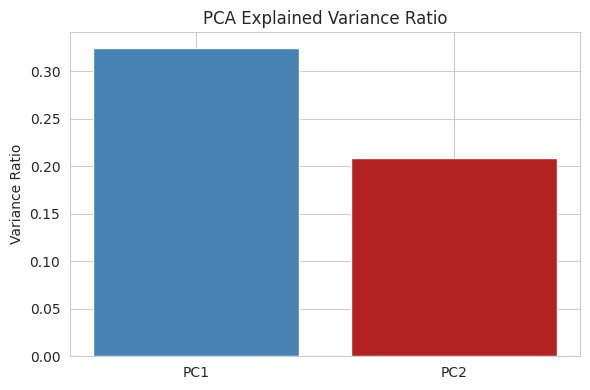

In [21]:
print("Explained variance ratio (PC1, PC2):", pca_2d.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], pca_2d.explained_variance_ratio_, color=["steelblue", "firebrick"])
plt.title("PCA Explained Variance Ratio")
plt.ylabel("Variance Ratio")
plt.tight_layout()
plt.show()


## 23. PCA Scatter Plot Comparison

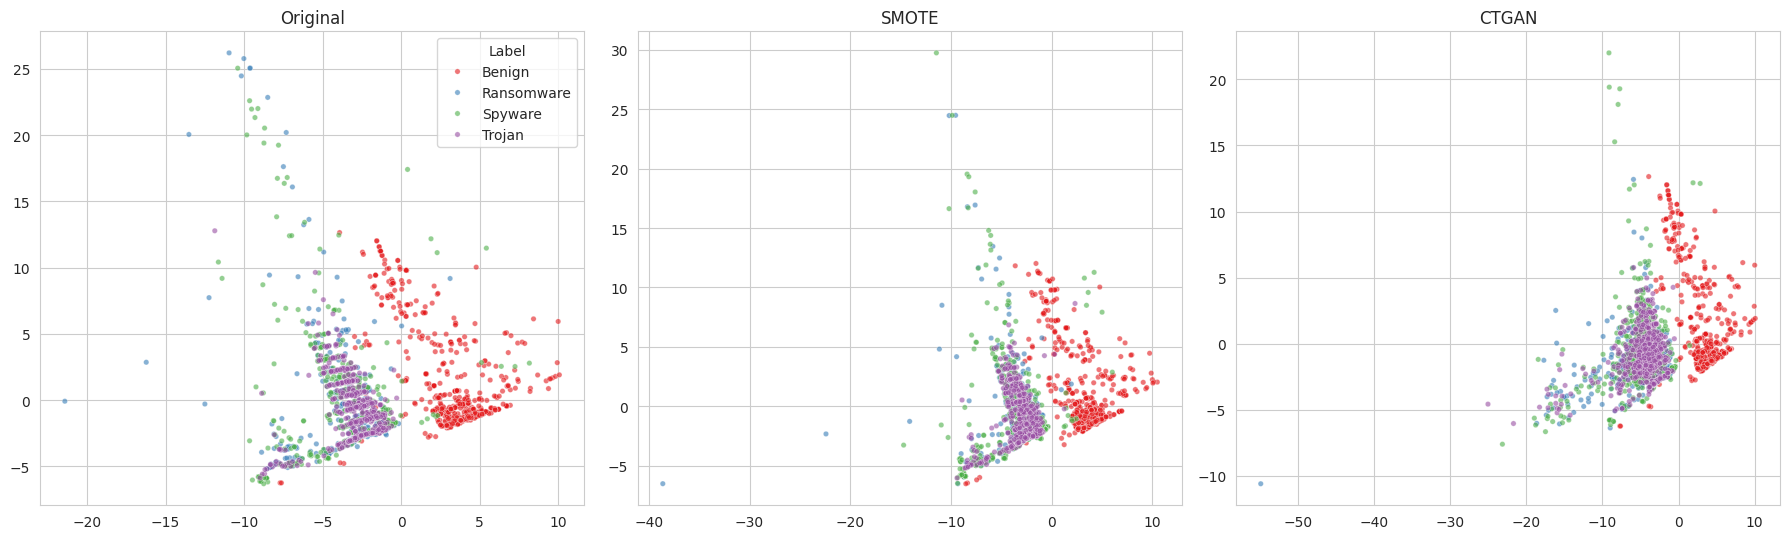

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, coords, sample, title in zip(
    axes, [orig_pca, smote_pca, ctgan_pca], [orig_sample, smote_sample, ctgan_sample],
    ["Original", "SMOTE", "CTGAN"]
):
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=sample["Label"], palette="Set1", alpha=0.6, s=15, ax=ax, legend=(title == "Original"))
    ax.set_title(title)
plt.tight_layout()
plt.show()


# ==========================================================
# t-SNE Visualization
# ==========================================================

## 24. Introduction to t-SNE

**t-distributed Stochastic Neighbor Embedding (t-SNE)** is a non-linear dimensionality
reduction technique that preserves local neighborhood structure, making it well suited to
revealing cluster structure that PCA's linear projection can miss.

## 25. Configure t-SNE Parameters

In [23]:
TSNE_SAMPLE_SIZE = 600  # reduced for CPU runtime; t-SNE is O(n^2)
TSNE_PERPLEXITY = 30

tsne_orig_sample = stratified_sample(orig_df, "Label", TSNE_SAMPLE_SIZE)
tsne_smote_sample = stratified_sample(smote_df, "Label", TSNE_SAMPLE_SIZE)
tsne_ctgan_sample = stratified_sample(ctgan_df, "Label", TSNE_SAMPLE_SIZE)

print(f"t-SNE sample sizes -> Original: {len(tsne_orig_sample)}, SMOTE: {len(tsne_smote_sample)}, CTGAN: {len(tsne_ctgan_sample)}")
print(f"perplexity={TSNE_PERPLEXITY}")


t-SNE sample sizes -> Original: 600, SMOTE: 600, CTGAN: 600
perplexity=30


## 26. Apply t-SNE to Original Dataset

In [24]:
tsne_orig = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=TSNE_PERPLEXITY, init="pca").fit_transform(
    pca_scaler.transform(tsne_orig_sample[feature_cols])
)
print("t-SNE (Original) done:", tsne_orig.shape)


t-SNE (Original) done: (600, 2)


## 27. Apply t-SNE to SMOTE Dataset

In [25]:
tsne_smote = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=TSNE_PERPLEXITY, init="pca").fit_transform(
    pca_scaler.transform(tsne_smote_sample[feature_cols])
)
print("t-SNE (SMOTE) done:", tsne_smote.shape)


t-SNE (SMOTE) done: (600, 2)


## 28. Apply t-SNE to CTGAN Dataset

In [26]:
tsne_ctgan = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=TSNE_PERPLEXITY, init="pca").fit_transform(
    pca_scaler.transform(tsne_ctgan_sample[feature_cols])
)
print("t-SNE (CTGAN) done:", tsne_ctgan.shape)


t-SNE (CTGAN) done: (600, 2)


## 29. Overlay Original vs SMOTE

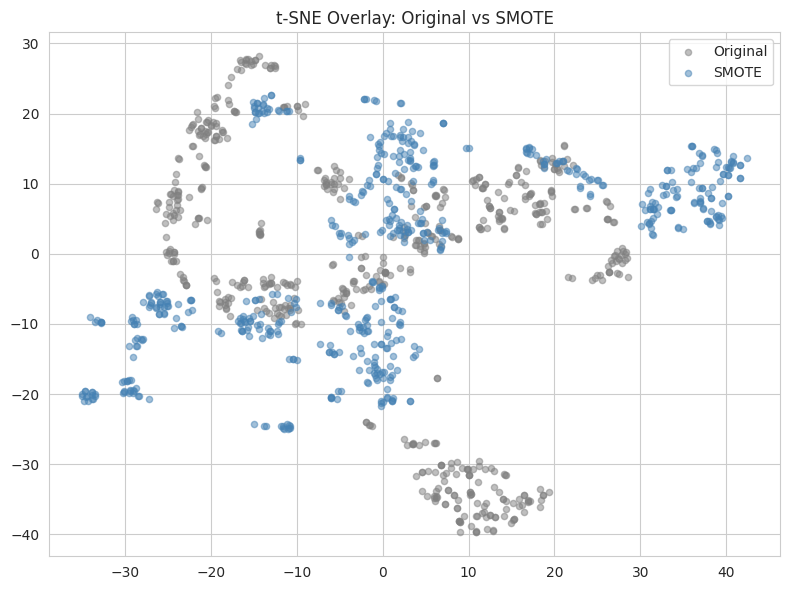

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(tsne_orig[:, 0], tsne_orig[:, 1], alpha=0.5, s=20, label="Original", color="gray")
plt.scatter(tsne_smote[:, 0], tsne_smote[:, 1], alpha=0.5, s=20, label="SMOTE", color="steelblue")
plt.title("t-SNE Overlay: Original vs SMOTE")
plt.legend()
plt.tight_layout()
plt.show()


## 30. Overlay Original vs CTGAN

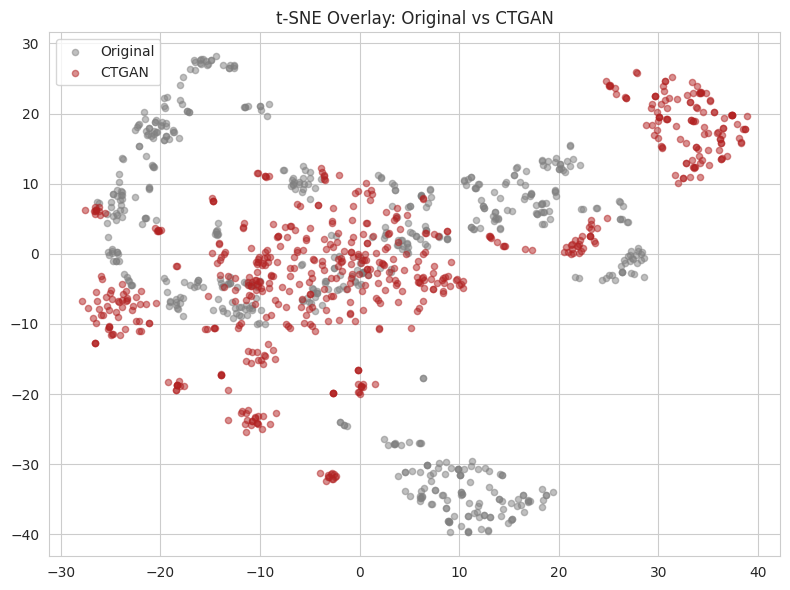

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(tsne_orig[:, 0], tsne_orig[:, 1], alpha=0.5, s=20, label="Original", color="gray")
plt.scatter(tsne_ctgan[:, 0], tsne_ctgan[:, 1], alpha=0.5, s=20, label="CTGAN", color="firebrick")
plt.title("t-SNE Overlay: Original vs CTGAN")
plt.legend()
plt.tight_layout()
plt.show()


## 31. t-SNE Scatter Plot Comparison

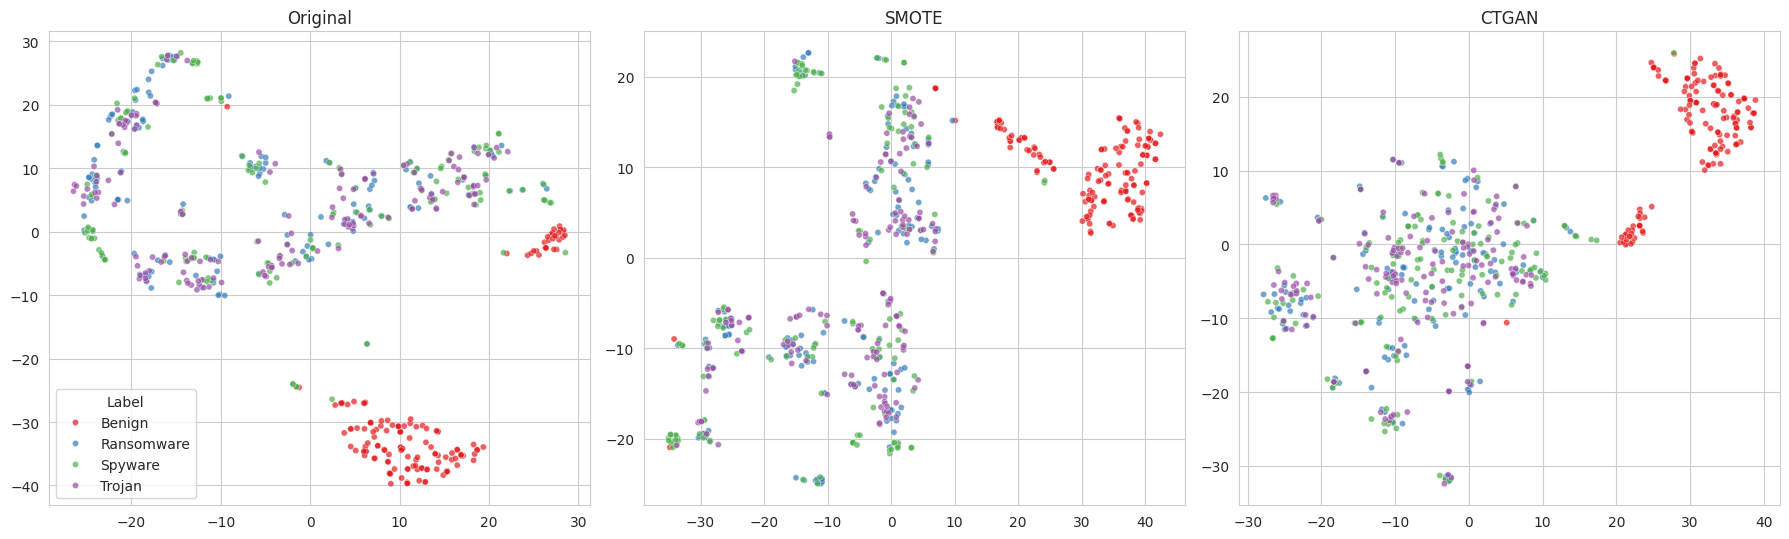

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, coords, sample, title in zip(
    axes, [tsne_orig, tsne_smote, tsne_ctgan], [tsne_orig_sample, tsne_smote_sample, tsne_ctgan_sample],
    ["Original", "SMOTE", "CTGAN"]
):
    sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=sample["Label"], palette="Set1", alpha=0.7, s=20, ax=ax, legend=(title == "Original"))
    ax.set_title(title)
plt.tight_layout()
plt.show()


# ==========================================================
# UMAP Visualization
# ==========================================================

## 32. Introduction to UMAP

**Uniform Manifold Approximation and Projection (UMAP)** is another non-linear embedding
technique. It tends to preserve more global structure than t-SNE while remaining much
faster, making it a useful cross-check on the t-SNE results above.

## 33. Configure UMAP Parameters

In [30]:
UMAP_SAMPLE_SIZE = 1000
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1

umap_orig_sample = stratified_sample(orig_df, "Label", UMAP_SAMPLE_SIZE)
umap_smote_sample = stratified_sample(smote_df, "Label", UMAP_SAMPLE_SIZE)
umap_ctgan_sample = stratified_sample(ctgan_df, "Label", UMAP_SAMPLE_SIZE)

print(f"UMAP available: {UMAP_AVAILABLE}")
print(f"n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST}, sample size={UMAP_SAMPLE_SIZE} per dataset")


UMAP available: True
n_neighbors=15, min_dist=0.1, sample size=1000 per dataset


## 34. Apply UMAP to Original Dataset

In [31]:
if UMAP_AVAILABLE:
    reducer_orig = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)
    umap_orig = reducer_orig.fit_transform(pca_scaler.transform(umap_orig_sample[feature_cols]))
    print("UMAP (Original) done:", umap_orig.shape)
else:
    umap_orig = None
    print("umap-learn not installed; skipping.")


UMAP (Original) done: (1000, 2)


## 35. Apply UMAP to SMOTE Dataset

In [32]:
if UMAP_AVAILABLE:
    reducer_smote = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)
    umap_smote = reducer_smote.fit_transform(pca_scaler.transform(umap_smote_sample[feature_cols]))
    print("UMAP (SMOTE) done:", umap_smote.shape)
else:
    umap_smote = None
    print("umap-learn not installed; skipping.")


UMAP (SMOTE) done: (1000, 2)


## 36. Apply UMAP to CTGAN Dataset

In [33]:
if UMAP_AVAILABLE:
    reducer_ctgan = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=RANDOM_STATE)
    umap_ctgan = reducer_ctgan.fit_transform(pca_scaler.transform(umap_ctgan_sample[feature_cols]))
    print("UMAP (CTGAN) done:", umap_ctgan.shape)
else:
    umap_ctgan = None
    print("umap-learn not installed; skipping.")


UMAP (CTGAN) done: (1000, 2)


## 37. Overlay Original vs SMOTE

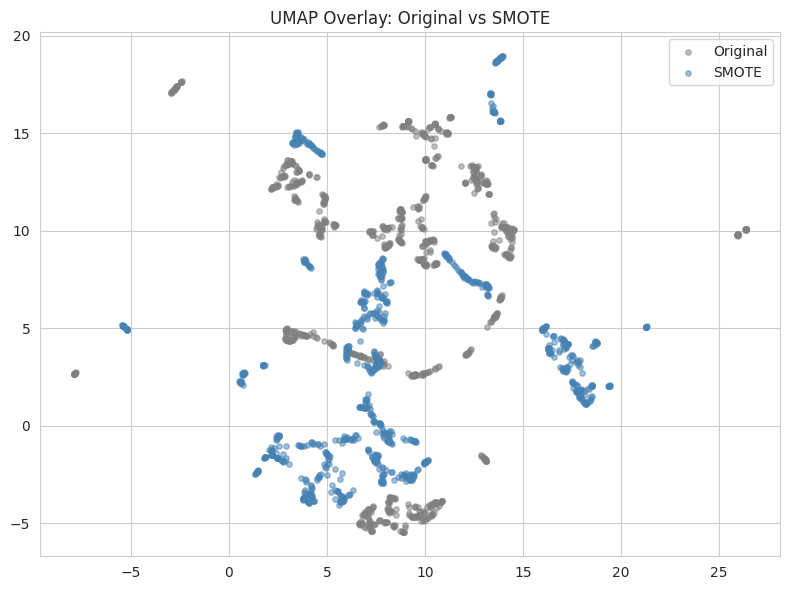

In [34]:
if UMAP_AVAILABLE:
    plt.figure(figsize=(8, 6))
    plt.scatter(umap_orig[:, 0], umap_orig[:, 1], alpha=0.5, s=15, label="Original", color="gray")
    plt.scatter(umap_smote[:, 0], umap_smote[:, 1], alpha=0.5, s=15, label="SMOTE", color="steelblue")
    plt.title("UMAP Overlay: Original vs SMOTE")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("umap-learn not installed; skipping.")


## 38. Overlay Original vs CTGAN

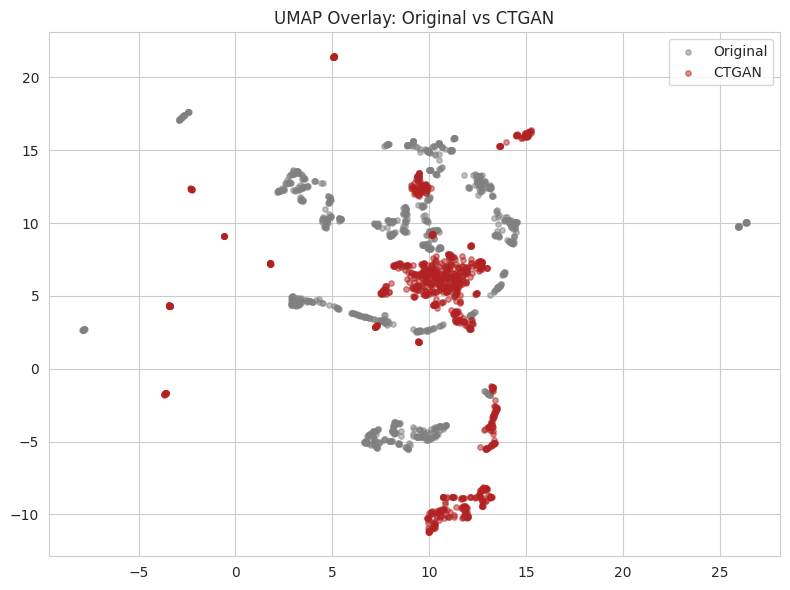

In [35]:
if UMAP_AVAILABLE:
    plt.figure(figsize=(8, 6))
    plt.scatter(umap_orig[:, 0], umap_orig[:, 1], alpha=0.5, s=15, label="Original", color="gray")
    plt.scatter(umap_ctgan[:, 0], umap_ctgan[:, 1], alpha=0.5, s=15, label="CTGAN", color="firebrick")
    plt.title("UMAP Overlay: Original vs CTGAN")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("umap-learn not installed; skipping.")


## 39. UMAP Scatter Plot Comparison

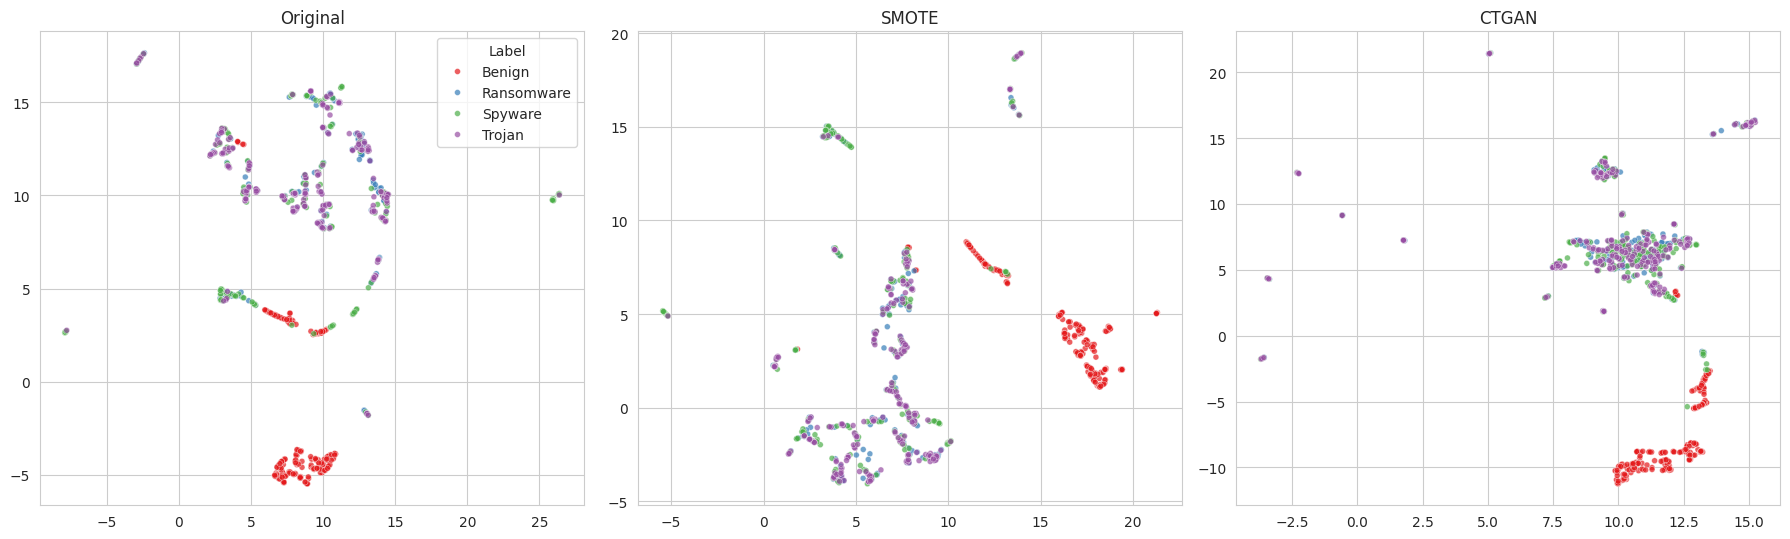

In [36]:
if UMAP_AVAILABLE:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for ax, coords, sample, title in zip(
        axes, [umap_orig, umap_smote, umap_ctgan], [umap_orig_sample, umap_smote_sample, umap_ctgan_sample],
        ["Original", "SMOTE", "CTGAN"]
    ):
        sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=sample["Label"], palette="Set1", alpha=0.7, s=18, ax=ax, legend=(title == "Original"))
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
else:
    print("umap-learn not installed; skipping.")


# ==========================================================
# Feature Distribution Comparison
# ==========================================================

In [37]:
top_var_features = orig_df[feature_cols].var().sort_values(ascending=False).head(4).index.tolist()
print("Top-variance features used for distribution plots:", top_var_features)


Top-variance features used for distribution plots: ['malfind.commitCharge', 'handles.nhandles', 'handles.nfile', 'handles.nevent']


## 40. Histogram Comparison

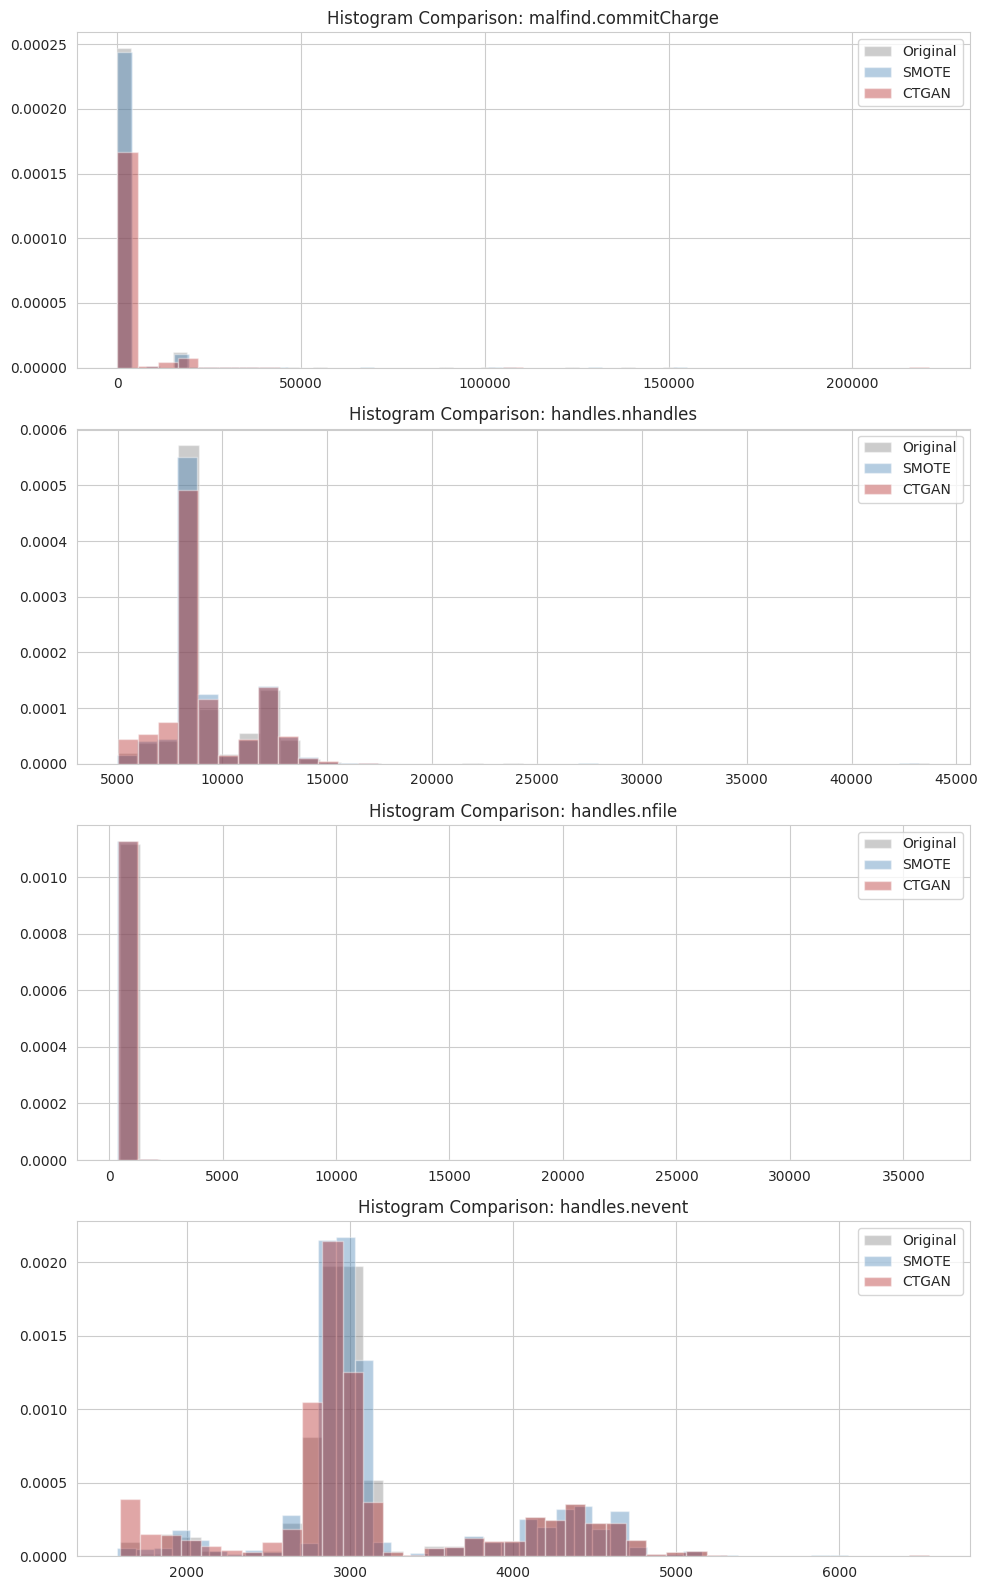

In [38]:
fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    ax.hist(orig_sample[feat], bins=40, alpha=0.4, label="Original", color="gray", density=True)
    ax.hist(smote_sample[feat], bins=40, alpha=0.4, label="SMOTE", color="steelblue", density=True)
    ax.hist(ctgan_sample[feat], bins=40, alpha=0.4, label="CTGAN", color="firebrick", density=True)
    ax.set_title(f"Histogram Comparison: {feat}")
    ax.legend()
plt.tight_layout()
plt.show()


## 41. KDE Plot Comparison

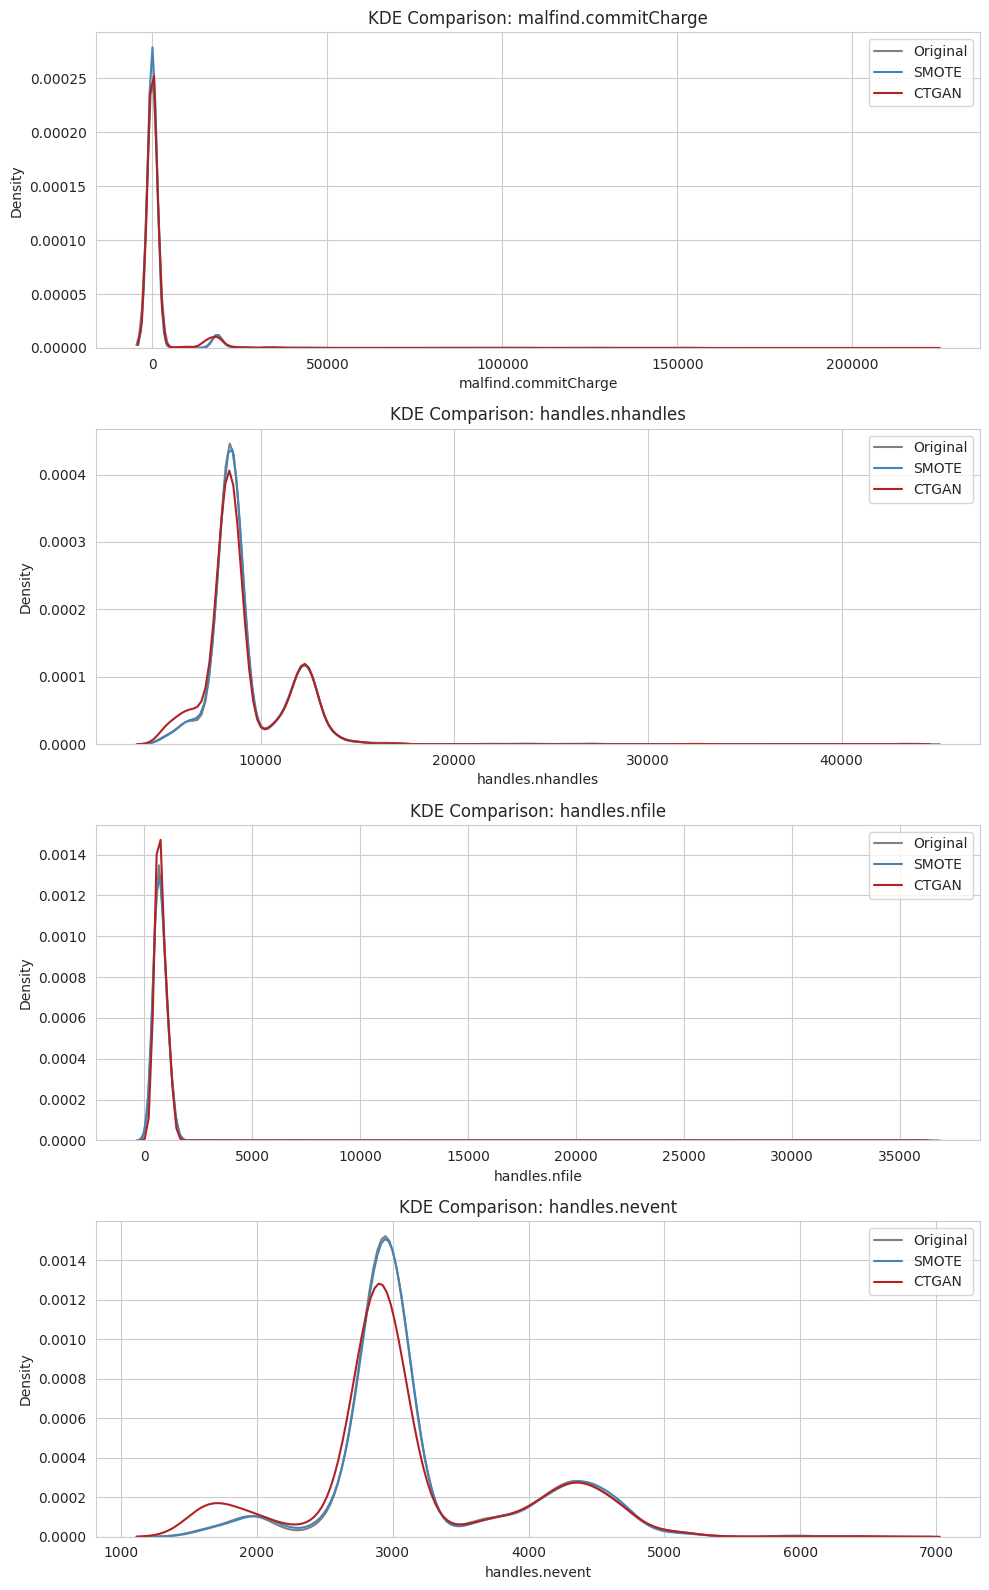

In [39]:
fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    sns.kdeplot(orig_sample[feat], ax=ax, label="Original", color="gray")
    sns.kdeplot(smote_sample[feat], ax=ax, label="SMOTE", color="steelblue")
    sns.kdeplot(ctgan_sample[feat], ax=ax, label="CTGAN", color="firebrick")
    ax.set_title(f"KDE Comparison: {feat}")
    ax.legend()
plt.tight_layout()
plt.show()


## 42. Density Plot Comparison

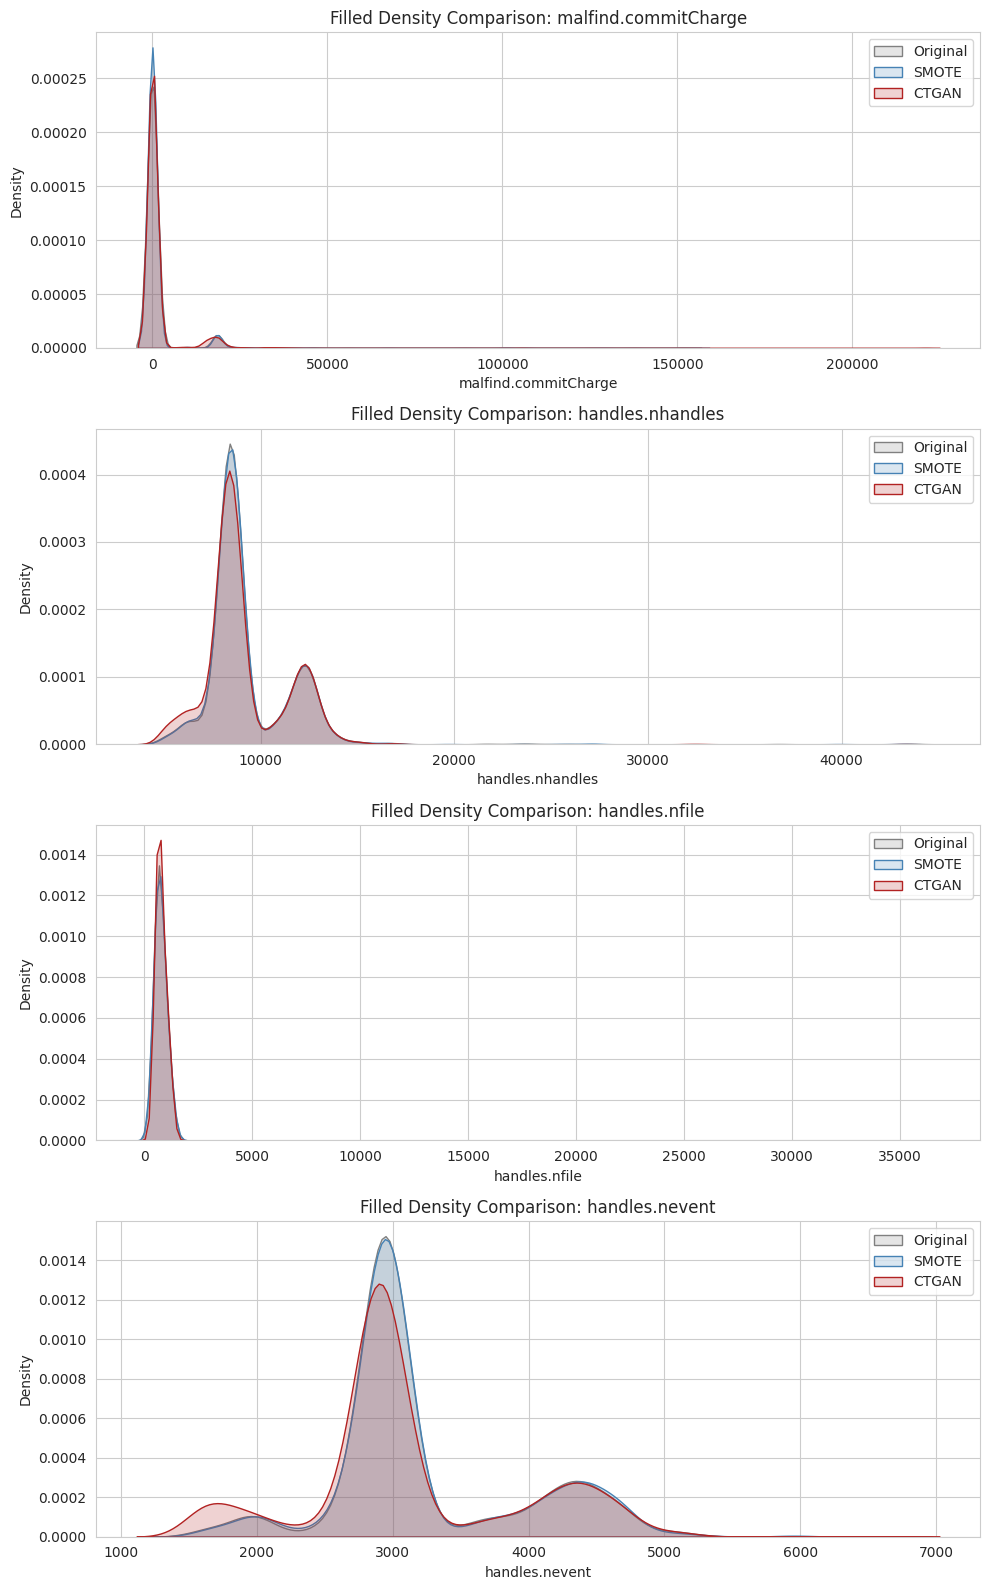

In [40]:
fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    sns.kdeplot(orig_sample[feat], ax=ax, label="Original", color="gray", fill=True, alpha=0.2)
    sns.kdeplot(smote_sample[feat], ax=ax, label="SMOTE", color="steelblue", fill=True, alpha=0.2)
    sns.kdeplot(ctgan_sample[feat], ax=ax, label="CTGAN", color="firebrick", fill=True, alpha=0.2)
    ax.set_title(f"Filled Density Comparison: {feat}")
    ax.legend()
plt.tight_layout()
plt.show()


## 43. Box Plot Comparison

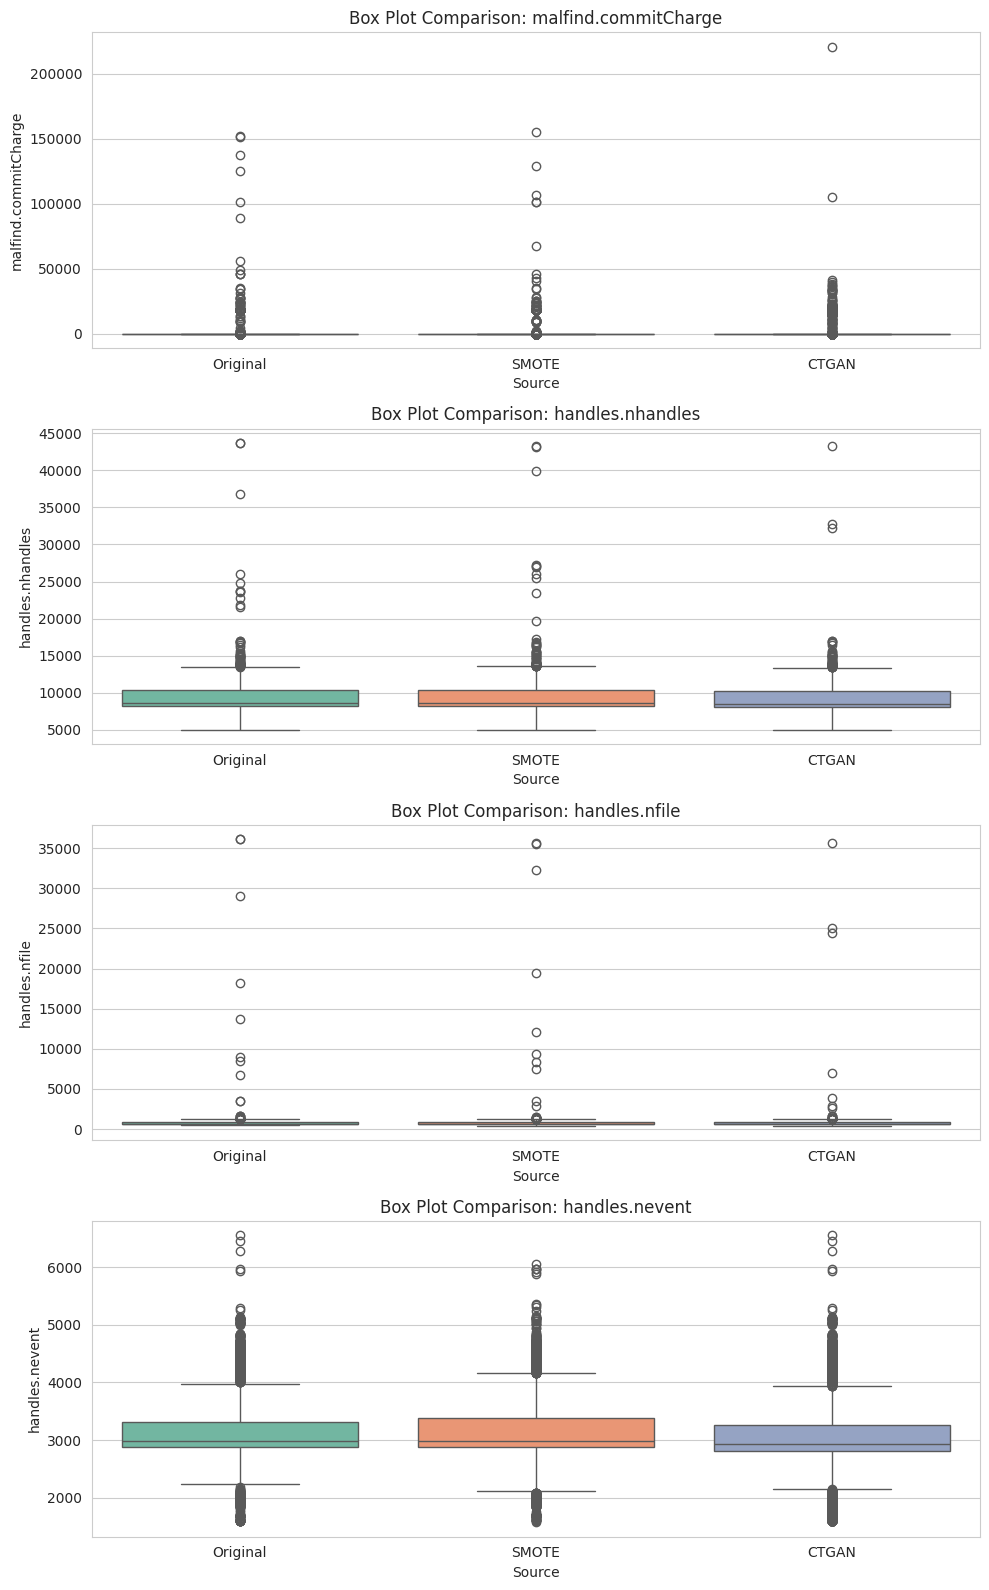

In [41]:
box_data = pd.concat([
    orig_sample.assign(Source="Original"),
    smote_sample.assign(Source="SMOTE"),
    ctgan_sample.assign(Source="CTGAN"),
], ignore_index=True)

fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    sns.boxplot(data=box_data, x="Source", y=feat, ax=ax, palette="Set2")
    ax.set_title(f"Box Plot Comparison: {feat}")
plt.tight_layout()
plt.show()


## 44. Violin Plot Comparison

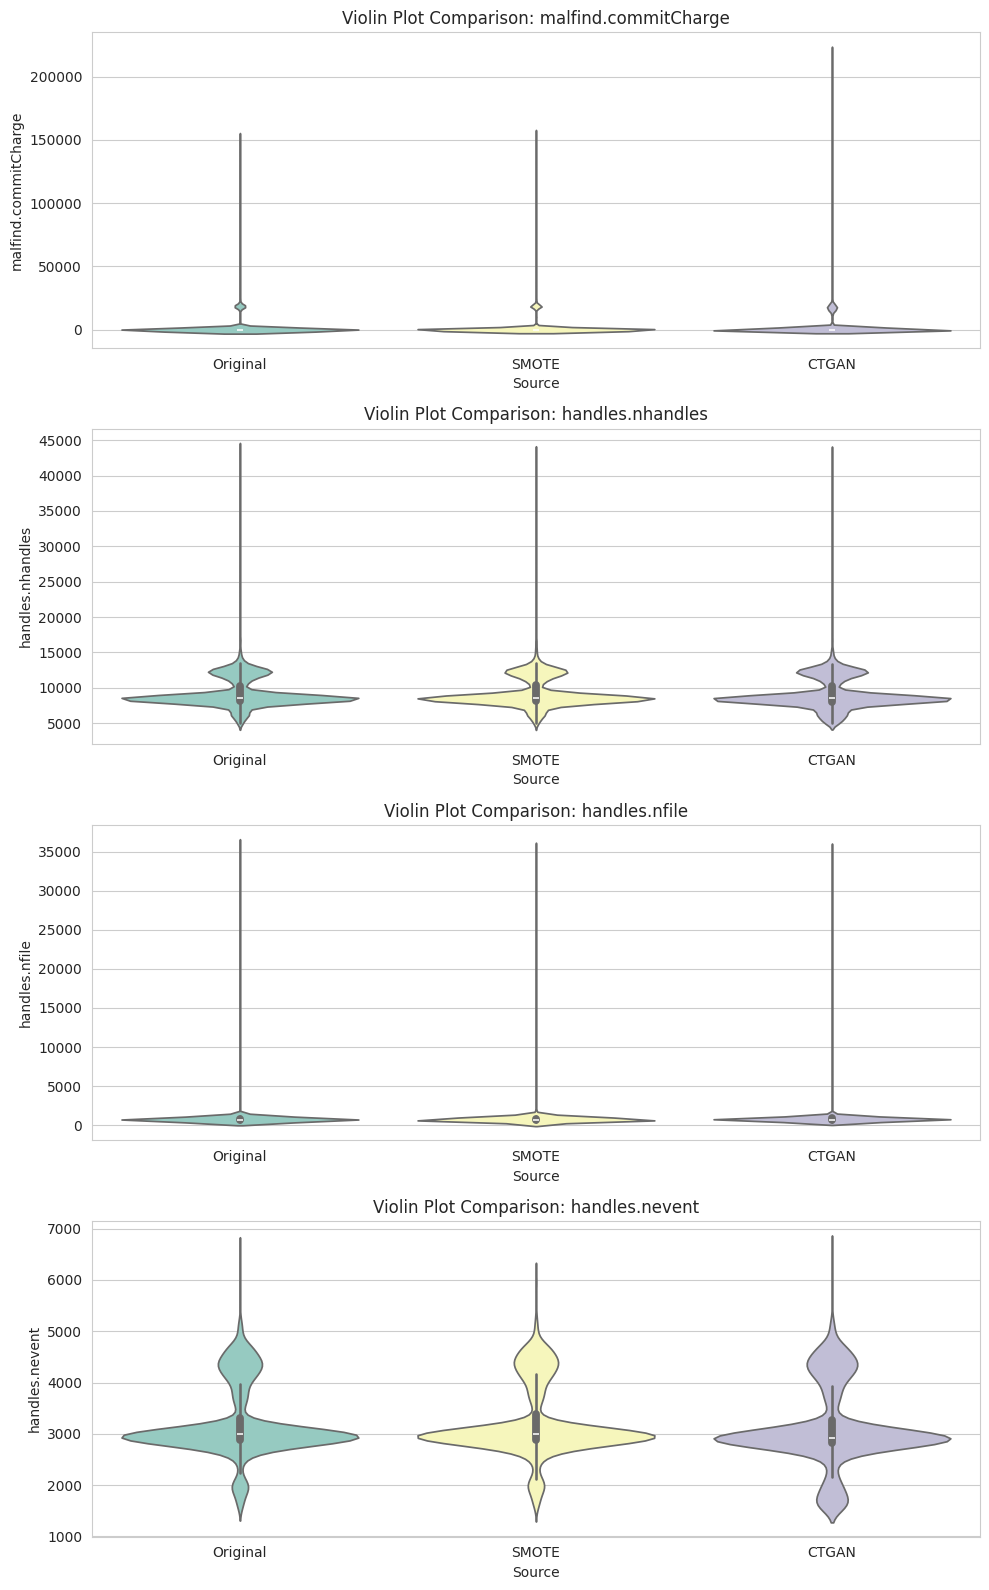

In [42]:
fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    sns.violinplot(data=box_data, x="Source", y=feat, ax=ax, palette="Set3")
    ax.set_title(f"Violin Plot Comparison: {feat}")
plt.tight_layout()
plt.show()


## 45. Boxen Plot Comparison

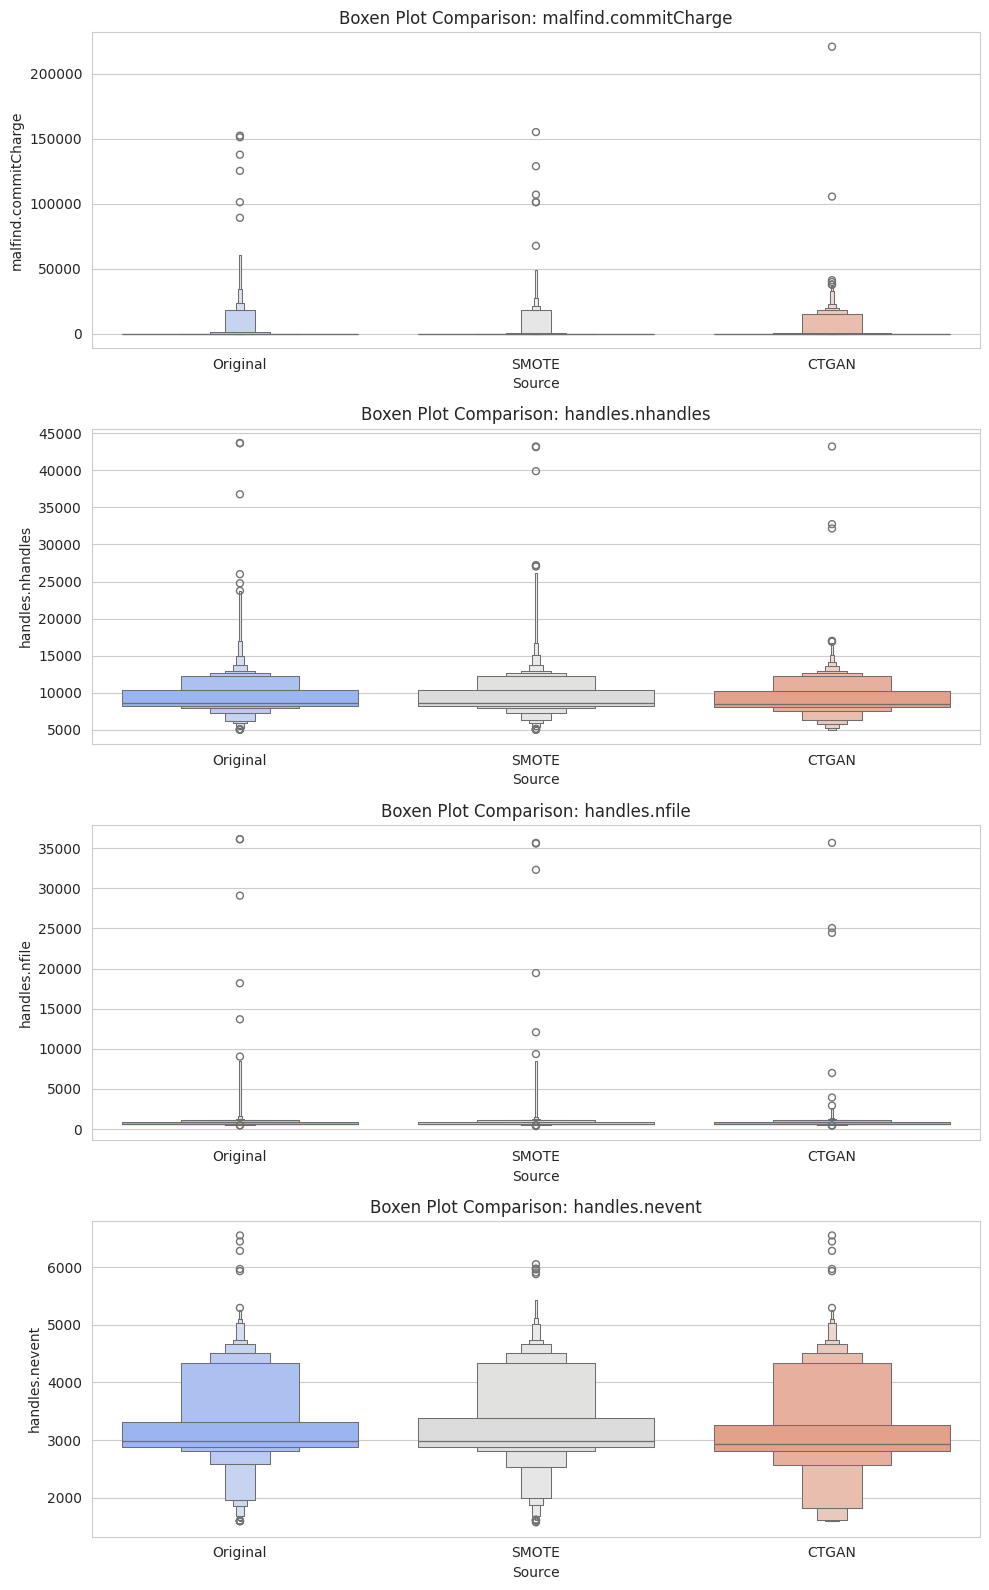

In [43]:
fig, axes = plt.subplots(len(top_var_features), 1, figsize=(10, 4 * len(top_var_features)))
for ax, feat in zip(axes, top_var_features):
    sns.boxenplot(data=box_data, x="Source", y=feat, ax=ax, palette="coolwarm")
    ax.set_title(f"Boxen Plot Comparison: {feat}")
plt.tight_layout()
plt.show()


## 46. Pair Plot (Sampled Data)

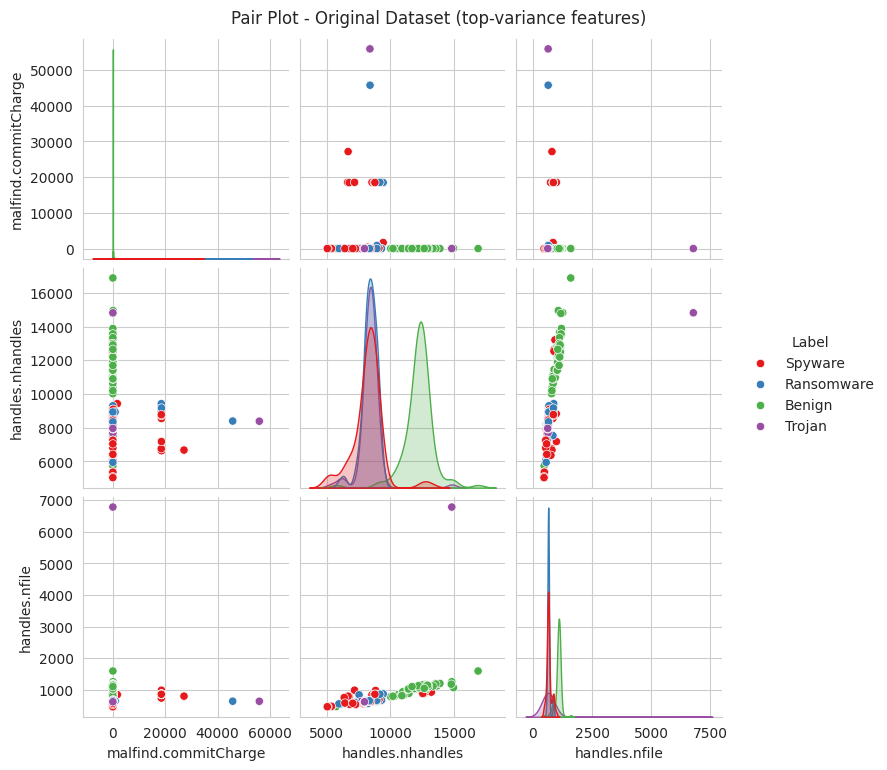

In [44]:
pairplot_features = top_var_features[:3] + ["Label"]
pairplot_sample = box_data[box_data["Source"] == "Original"][pairplot_features].sample(
    min(400, (box_data["Source"] == "Original").sum()), random_state=RANDOM_STATE
)
sns.pairplot(pairplot_sample, hue="Label", palette="Set1", diag_kind="kde", height=2.5)
plt.suptitle("Pair Plot - Original Dataset (top-variance features)", y=1.02)
plt.show()


# ==========================================================
# Statistical Quality Evaluation
# ==========================================================

## 47. Compare Mean

In [45]:
mean_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].mean(),
    "SMOTE": smote_df[feature_cols].mean(),
    "CTGAN": ctgan_df[feature_cols].mean(),
})
mean_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,41.407547,40.784132,41.043387
pslist.nppid,14.709552,15.265069,15.006226
pslist.avg_threads,11.350512,10.710034,10.586974
pslist.nprocs64bit,0.000000,0.000000,0.000000
pslist.avg_handlers,247.802426,228.506523,227.424943
dlllist.ndlls,1812.960439,1675.548817,1658.776299
dlllist.avg_dlls_per_proc,43.745115,41.104778,41.073289
handles.nhandles,10274.146016,9317.571686,9154.447675
handles.avg_handles_per_proc,249.853387,230.413490,227.406780
handles.nport,0.000000,0.000000,0.000000


## 48. Compare Median

In [46]:
median_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].median(),
    "SMOTE": smote_df[feature_cols].median(),
    "CTGAN": ctgan_df[feature_cols].median(),
})
median_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,41.000000,41.000000,41.000000
pslist.nppid,15.000000,16.000000,15.000000
pslist.avg_threads,11.022727,10.135135,10.081081
pslist.nprocs64bit,0.000000,0.000000,0.000000
pslist.avg_handlers,244.783765,212.087138,212.833333
dlllist.ndlls,1739.000000,1605.000000,1607.000000
dlllist.avg_dlls_per_proc,42.977048,39.065243,39.081081
handles.nhandles,9439.500000,8605.000000,8549.000000
handles.avg_handles_per_proc,248.307436,214.024390,211.859499
handles.nport,0.000000,0.000000,0.000000


## 49. Compare Standard Deviation

In [47]:
std_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].std(),
    "SMOTE": smote_df[feature_cols].std(),
    "CTGAN": ctgan_df[feature_cols].std(),
})
std_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,5.777920,5.934438,5.648736
pslist.nppid,2.661196,2.543553,2.407065
pslist.avg_threads,1.587684,1.448519,1.557153
pslist.nprocs64bit,0.000000,0.000000,0.000000
pslist.avg_handlers,112.285446,85.117193,82.768749
dlllist.ndlls,329.856293,290.709328,311.005774
dlllist.avg_dlls_per_proc,5.738297,5.008140,5.134180
handles.nhandles,4884.605333,3734.476287,3708.284659
handles.avg_handles_per_proc,146.609930,107.814296,106.578939
handles.nport,0.000000,0.000000,0.000000


## 50. Compare Variance

In [48]:
var_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].var(),
    "SMOTE": smote_df[feature_cols].var(),
    "CTGAN": ctgan_df[feature_cols].var(),
})
var_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,3.338436e+01,3.521756e+01,3.190822e+01
pslist.nppid,7.081963e+00,6.469660e+00,5.793962e+00
pslist.avg_threads,2.520740e+00,2.098206e+00,2.424724e+00
pslist.nprocs64bit,0.000000e+00,0.000000e+00,0.000000e+00
pslist.avg_handlers,1.260802e+04,7.244937e+03,6.850666e+03
dlllist.ndlls,1.088052e+05,8.451191e+04,9.672459e+04
dlllist.avg_dlls_per_proc,3.292806e+01,2.508147e+01,2.635980e+01
handles.nhandles,2.385937e+07,1.394631e+07,1.375138e+07
handles.avg_handles_per_proc,2.149447e+04,1.162392e+04,1.135907e+04
handles.nport,0.000000e+00,0.000000e+00,0.000000e+00


## 51. Compare Skewness

In [49]:
skew_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].skew(),
    "SMOTE": smote_df[feature_cols].skew(),
    "CTGAN": ctgan_df[feature_cols].skew(),
})
skew_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,7.090143,7.607884,4.634238
pslist.nppid,2.923184,3.968005,1.721536
pslist.avg_threads,0.113675,0.839310,0.523319
pslist.nprocs64bit,0.000000,0.000000,0.000000
pslist.avg_handlers,181.243553,207.190119,225.362644
dlllist.ndlls,0.318208,0.985738,0.637503
dlllist.avg_dlls_per_proc,-0.025818,0.759642,0.678078
handles.nhandles,164.968874,183.901788,187.957263
handles.avg_handles_per_proc,206.189843,257.594698,267.113651
handles.nport,0.000000,0.000000,0.000000


## 52. Compare Kurtosis

In [50]:
kurt_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].kurtosis(),
    "SMOTE": smote_df[feature_cols].kurtosis(),
    "CTGAN": ctgan_df[feature_cols].kurtosis(),
})
kurt_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,142.324064,142.826659,87.729793
pslist.nppid,42.760106,63.614336,32.350632
pslist.avg_threads,-0.286905,1.589801,1.552534
pslist.nprocs64bit,0.000000,0.000000,0.000000
pslist.avg_handlers,39669.298802,59710.282165,66941.986114
dlllist.ndlls,0.264281,1.922791,1.079812
dlllist.avg_dlls_per_proc,-0.661345,1.231013,0.677926
handles.nhandles,34993.743166,50932.657988,52537.347689
handles.avg_handles_per_proc,47145.627079,80054.109313,84051.790790
handles.nport,0.000000,0.000000,0.000000


## 53. Compare Feature Ranges

In [51]:
range_comp = pd.DataFrame({
    "Original": orig_df[feature_cols].max() - orig_df[feature_cols].min(),
    "SMOTE": smote_df[feature_cols].max() - smote_df[feature_cols].min(),
    "CTGAN": ctgan_df[feature_cols].max() - ctgan_df[feature_cols].min(),
})
range_comp.head(10)


,Original,SMOTE,CTGAN
pslist.nproc,2.190000e+02,2.190000e+02,2.190000e+02
pslist.nppid,6.400000e+01,6.400000e+01,6.400000e+01
pslist.avg_threads,1.516818e+01,1.516818e+01,1.516818e+01
pslist.nprocs64bit,0.000000e+00,0.000000e+00,0.000000e+00
pslist.avg_handlers,2.481099e+04,2.481099e+04,2.481099e+04
dlllist.ndlls,2.773000e+03,2.773000e+03,2.773000e+03
dlllist.avg_dlls_per_proc,4.583740e+01,4.583740e+01,4.583740e+01
handles.nhandles,1.043796e+06,1.043796e+06,1.043796e+06
handles.avg_handles_per_proc,3.371305e+04,3.371305e+04,3.371305e+04
handles.nport,0.000000e+00,0.000000e+00,0.000000e+00


# ==========================================================
# Correlation Analysis
# ==========================================================

In [52]:
corr_features = top_var_features + orig_df[feature_cols].var().sort_values(ascending=False).index[4:15].tolist()


## 54. Correlation Matrix (Original)

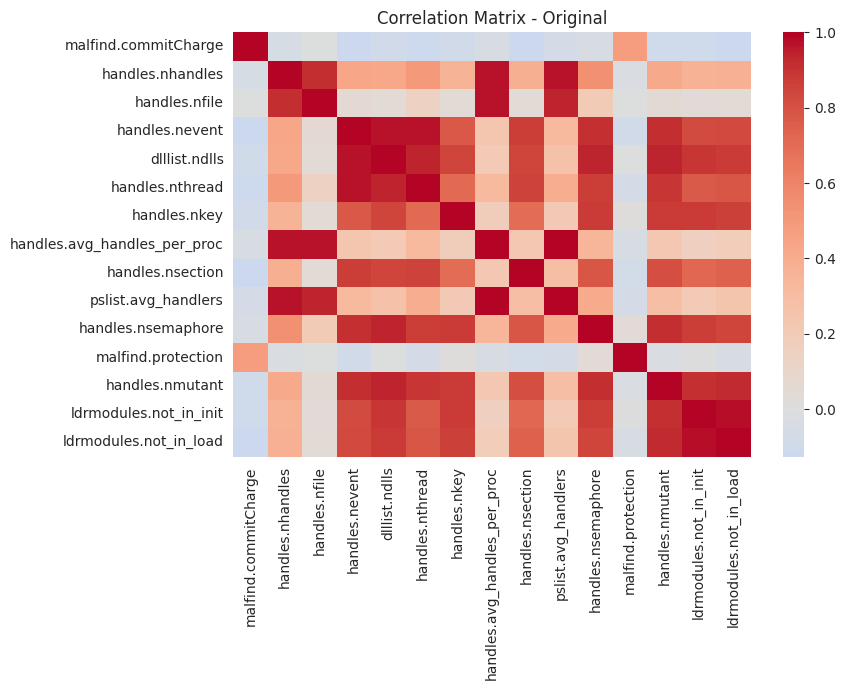

In [53]:
corr_orig = orig_df[corr_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_orig, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix - Original")
plt.tight_layout()
plt.show()


## 55. Correlation Matrix (SMOTE)

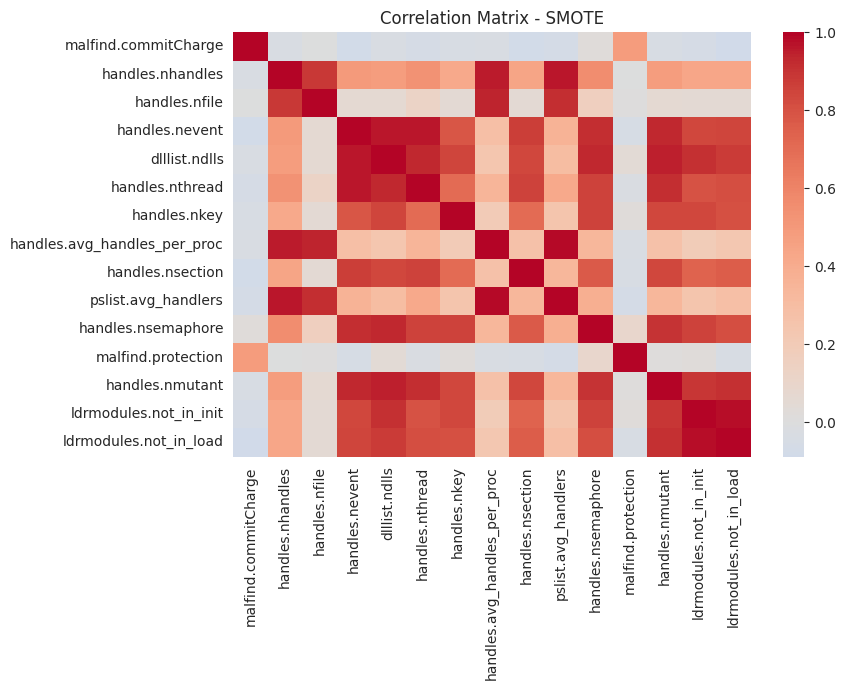

In [54]:
corr_smote = smote_df[corr_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_smote, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix - SMOTE")
plt.tight_layout()
plt.show()


## 56. Correlation Matrix (CTGAN)

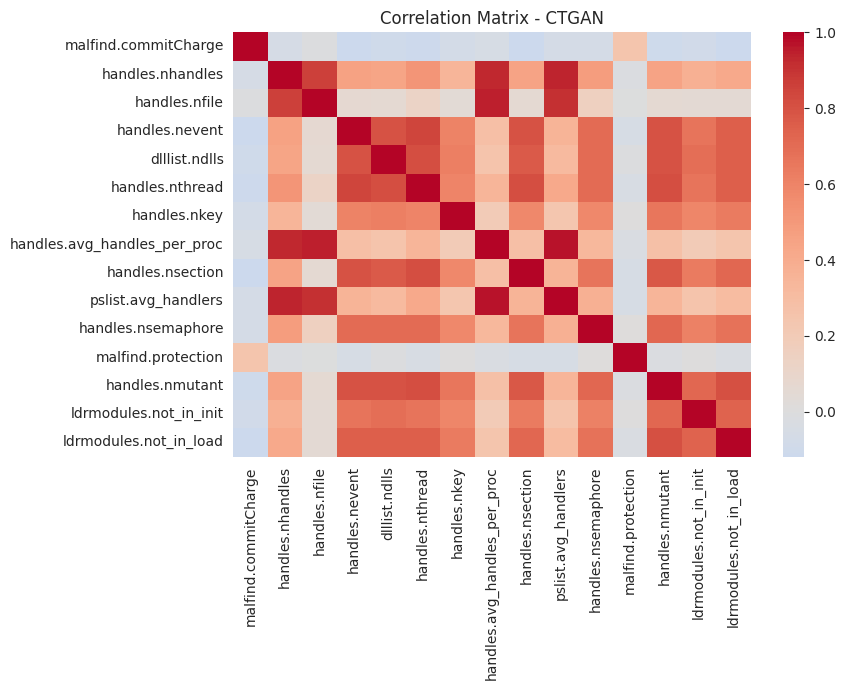

In [55]:
corr_ctgan = ctgan_df[corr_features].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr_ctgan, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix - CTGAN")
plt.tight_layout()
plt.show()


## 57. Correlation Heatmap Comparison

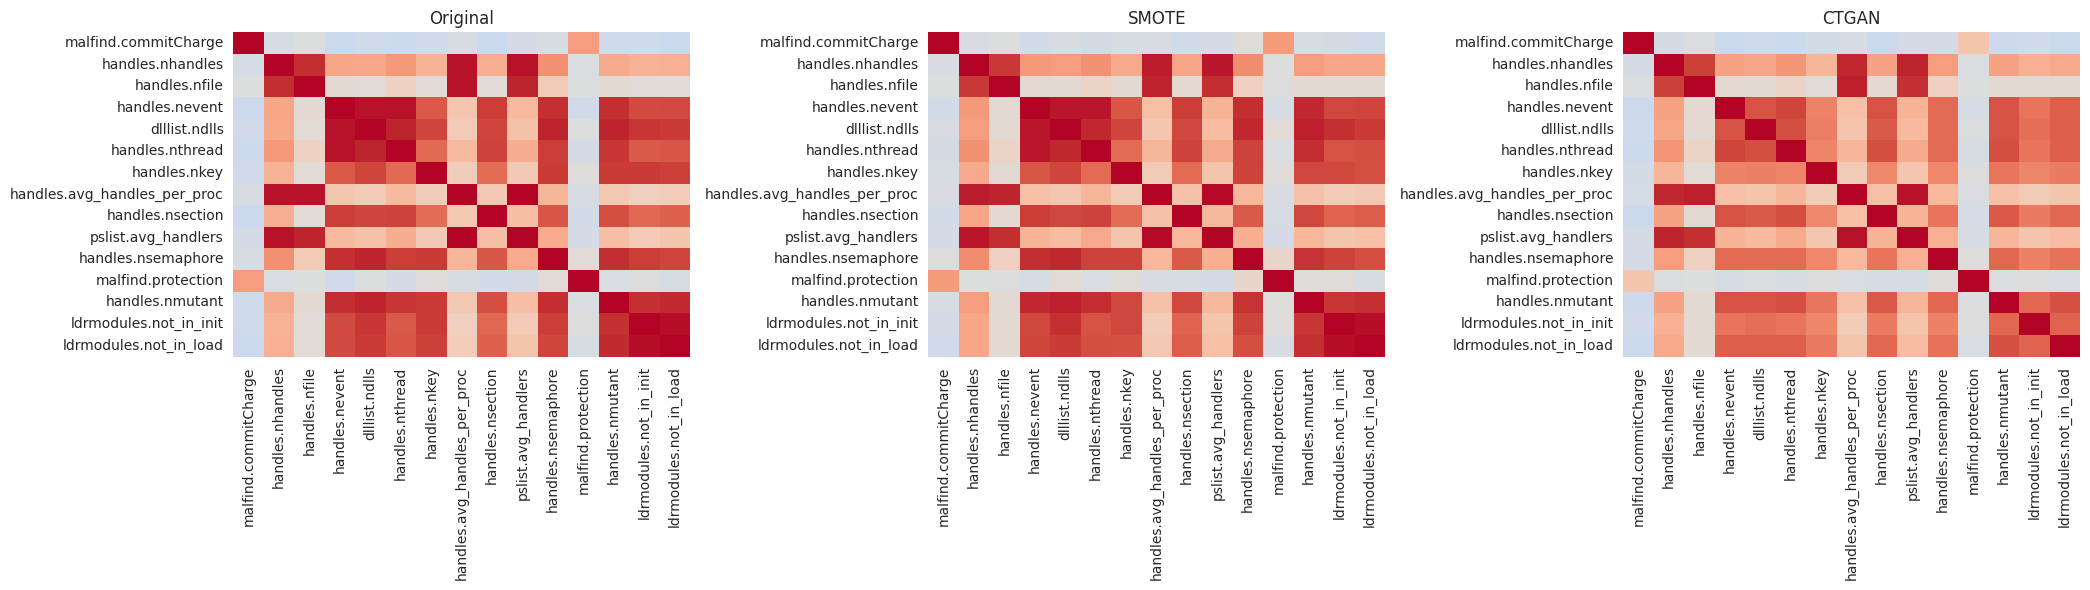

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, corr, title in zip(axes, [corr_orig, corr_smote, corr_ctgan], ["Original", "SMOTE", "CTGAN"]):
    sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, cbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 58. Correlation Difference Matrix

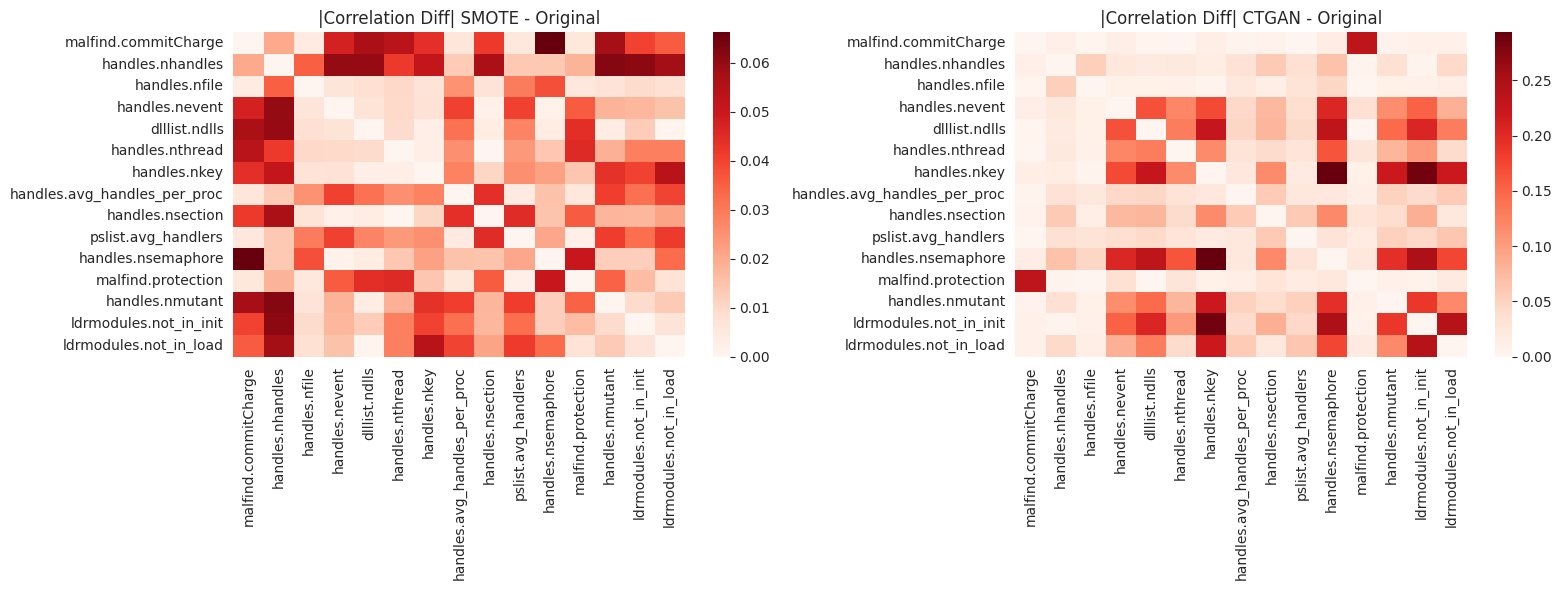

Mean absolute correlation difference (SMOTE): 0.0233
Mean absolute correlation difference (CTGAN): 0.0644


In [57]:
diff_smote = (corr_smote - corr_orig).abs()
diff_ctgan = (corr_ctgan - corr_orig).abs()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(diff_smote, ax=axes[0], cmap="Reds")
axes[0].set_title("|Correlation Diff| SMOTE - Original")
sns.heatmap(diff_ctgan, ax=axes[1], cmap="Reds")
axes[1].set_title("|Correlation Diff| CTGAN - Original")
plt.tight_layout()
plt.show()

print(f"Mean absolute correlation difference (SMOTE): {diff_smote.values.mean():.4f}")
print(f"Mean absolute correlation difference (CTGAN): {diff_ctgan.values.mean():.4f}")


# ==========================================================
# Similarity Metrics
# ==========================================================

The metrics below focus on the **minority classes** (Ransomware, Spyware, Trojan) — the
classes that were actually rebalanced — comparing real minority samples against the
minority-class rows of the SMOTE and CTGAN datasets.

In [58]:
minority_classes = ["Ransomware", "Spyware", "Trojan"]

orig_minority = orig_df[orig_df["Label"].isin(minority_classes)].reset_index(drop=True)
smote_minority = smote_df[smote_df["Label"].isin(minority_classes)].reset_index(drop=True)
ctgan_minority = ctgan_df[ctgan_df["Label"].isin(minority_classes)].reset_index(drop=True)

# Isolate rows that are genuinely NEW (not exact copies of real original rows).
# Uses a hash-based set-membership check (robust to duplicate keys, unlike a merge-based
# anti-join, which can multiply rows when either side contains duplicate key combinations).
def synthetic_only(balanced_minority, real_minority):
    key_cols = feature_cols + ["Label"]
    real_keys = set(pd.util.hash_pandas_object(real_minority[key_cols], index=False))
    balanced_keys = pd.util.hash_pandas_object(balanced_minority[key_cols], index=False)
    mask = ~balanced_keys.isin(real_keys)
    return balanced_minority[mask.values].reset_index(drop=True)

smote_synth = synthetic_only(smote_minority, orig_minority)
ctgan_synth = synthetic_only(ctgan_minority, orig_minority)

print(f"Real minority samples       : {len(orig_minority)}")
print(f"SMOTE minority (total/new)  : {len(smote_minority)} / {len(smote_synth)}")
print(f"CTGAN minority (total/new)  : {len(ctgan_minority)} / {len(ctgan_synth)}")


Real minority samples       : 28831
SMOTE minority (total/new)  : 87894 / 58099
CTGAN minority (total/new)  : 87693 / 58862


In [59]:
SIM_SAMPLE = 1500
real_ref = orig_minority[feature_cols].sample(min(SIM_SAMPLE, len(orig_minority)), random_state=RANDOM_STATE).values
smote_ref = smote_synth[feature_cols].sample(min(SIM_SAMPLE, len(smote_synth)), random_state=RANDOM_STATE).values if len(smote_synth) else np.empty((0, len(feature_cols)))
ctgan_ref = ctgan_synth[feature_cols].sample(min(SIM_SAMPLE, len(ctgan_synth)), random_state=RANDOM_STATE).values if len(ctgan_synth) else np.empty((0, len(feature_cols)))

sim_scaler = StandardScaler().fit(real_ref)
real_ref_s = sim_scaler.transform(real_ref)
smote_ref_s = sim_scaler.transform(smote_ref) if len(smote_ref) else smote_ref
ctgan_ref_s = sim_scaler.transform(ctgan_ref) if len(ctgan_ref) else ctgan_ref

print(f"Similarity-metric sample sizes -> real: {len(real_ref)}, SMOTE-synth: {len(smote_ref)}, CTGAN-synth: {len(ctgan_ref)}")


Similarity-metric sample sizes -> real: 1500, SMOTE-synth: 1500, CTGAN-synth: 1500


## 59. Kolmogorov–Smirnov (KS) Test

In [60]:
ks_results = []
for i, feat in enumerate(feature_cols):
    ks_smote = ks_2samp(real_ref[:, i], smote_ref[:, i]) if len(smote_ref) else None
    ks_ctgan = ks_2samp(real_ref[:, i], ctgan_ref[:, i]) if len(ctgan_ref) else None
    ks_results.append({
        "Feature": feat,
        "SMOTE_KS_stat": ks_smote.statistic if ks_smote else np.nan,
        "SMOTE_p_value": ks_smote.pvalue if ks_smote else np.nan,
        "CTGAN_KS_stat": ks_ctgan.statistic if ks_ctgan else np.nan,
        "CTGAN_p_value": ks_ctgan.pvalue if ks_ctgan else np.nan,
    })
ks_df = pd.DataFrame(ks_results)
print("Mean KS statistic (lower = more similar to real):")
print(f"  SMOTE : {ks_df['SMOTE_KS_stat'].mean():.4f}")
print(f"  CTGAN : {ks_df['CTGAN_KS_stat'].mean():.4f}")
ks_df.head(10)


Mean KS statistic (lower = more similar to real):
  SMOTE : 0.0310
  CTGAN : 0.1934


,Feature,SMOTE_KS_stat,SMOTE_p_value,CTGAN_KS_stat,CTGAN_p_value
0,pslist.nproc,0.028000,0.599116,0.126000,8.603488e-11
1,pslist.nppid,0.022000,0.861129,0.184000,1.340077e-22
2,pslist.avg_threads,0.040000,0.181330,0.298667,2.066586e-59
3,pslist.nprocs64bit,0.000000,1.000000,0.000000,1.000000e+00
4,pslist.avg_handlers,0.031333,0.453225,0.099333,7.323560e-07
5,dlllist.ndlls,0.032667,0.400319,0.158667,6.869621e-17
6,dlllist.avg_dlls_per_proc,0.035333,0.306386,0.090000,1.044650e-05
7,handles.nhandles,0.033333,0.375307,0.158667,6.869621e-17
8,handles.avg_handles_per_proc,0.042000,0.141833,0.197333,5.956168e-26
9,handles.nport,0.000000,1.000000,0.000000,1.000000e+00


## 60. Wasserstein Distance

In [61]:
wass_results = []
for i, feat in enumerate(feature_cols):
    w_smote = wasserstein_distance(real_ref[:, i], smote_ref[:, i]) if len(smote_ref) else np.nan
    w_ctgan = wasserstein_distance(real_ref[:, i], ctgan_ref[:, i]) if len(ctgan_ref) else np.nan
    wass_results.append({"Feature": feat, "SMOTE_Wasserstein": w_smote, "CTGAN_Wasserstein": w_ctgan})
wass_df = pd.DataFrame(wass_results)
print("Mean Wasserstein distance (lower = more similar to real):")
print(f"  SMOTE : {wass_df['SMOTE_Wasserstein'].mean():.4f}")
print(f"  CTGAN : {wass_df['CTGAN_Wasserstein'].mean():.4f}")
wass_df.head(10)


Mean Wasserstein distance (lower = more similar to real):
  SMOTE : 9.6483
  CTGAN : 32.3777


,Feature,SMOTE_Wasserstein,CTGAN_Wasserstein
0,pslist.nproc,0.378000,1.043333
1,pslist.nppid,0.143333,0.536667
2,pslist.avg_threads,0.075836,0.333455
3,pslist.nprocs64bit,0.000000,0.000000
4,pslist.avg_handlers,1.431144,4.134748
5,dlllist.ndlls,11.428667,52.722000
6,dlllist.avg_dlls_per_proc,0.140338,0.494133
7,handles.nhandles,80.534000,299.620667
8,handles.avg_handles_per_proc,1.359338,6.637913
9,handles.nport,0.000000,0.000000


## 61. Jensen-Shannon Distance (Optional)

In [62]:
def js_distance_1d(a, b, bins=50):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    if lo == hi:
        return 0.0
    hist_a, edges = np.histogram(a, bins=bins, range=(lo, hi), density=True)
    hist_b, _ = np.histogram(b, bins=bins, range=(lo, hi), density=True)
    hist_a = hist_a + 1e-12
    hist_b = hist_b + 1e-12
    return jensenshannon(hist_a, hist_b)

js_results = []
for i, feat in enumerate(feature_cols):
    js_smote = js_distance_1d(real_ref[:, i], smote_ref[:, i]) if len(smote_ref) else np.nan
    js_ctgan = js_distance_1d(real_ref[:, i], ctgan_ref[:, i]) if len(ctgan_ref) else np.nan
    js_results.append({"Feature": feat, "SMOTE_JS": js_smote, "CTGAN_JS": js_ctgan})
js_df = pd.DataFrame(js_results)
print("Mean Jensen-Shannon distance (lower = more similar to real):")
print(f"  SMOTE : {js_df['SMOTE_JS'].mean():.4f}")
print(f"  CTGAN : {js_df['CTGAN_JS'].mean():.4f}")
js_df.head(10)


Mean Jensen-Shannon distance (lower = more similar to real):
  SMOTE : 0.0641
  CTGAN : 0.1874


,Feature,SMOTE_JS,CTGAN_JS
0,pslist.nproc,0.077032,0.156175
1,pslist.nppid,0.074349,0.169284
2,pslist.avg_threads,0.092214,0.304868
3,pslist.nprocs64bit,0.000000,0.000000
4,pslist.avg_handlers,0.082642,0.168441
5,dlllist.ndlls,0.071157,0.215111
6,dlllist.avg_dlls_per_proc,0.081795,0.183836
7,handles.nhandles,0.082242,0.170310
8,handles.avg_handles_per_proc,0.070520,0.248746
9,handles.nport,0.000000,0.000000


## 62. Cosine Similarity

In [63]:
def mean_cosine_similarity(real, synth, n_pairs=500, seed=RANDOM_STATE):
    if len(synth) == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    idx_real = rng.randint(0, len(real), n_pairs)
    idx_synth = rng.randint(0, len(synth), n_pairs)
    sims = [1 - cosine(real[a], synth[b]) for a, b in zip(idx_real, idx_synth)]
    return float(np.mean(sims))

cos_smote = mean_cosine_similarity(real_ref_s, smote_ref_s)
cos_ctgan = mean_cosine_similarity(real_ref_s, ctgan_ref_s)
print(f"Mean cosine similarity (higher = more similar to real):")
print(f"  SMOTE : {cos_smote:.4f}")
print(f"  CTGAN : {cos_ctgan:.4f}")


Mean cosine similarity (higher = more similar to real):
  SMOTE : 0.0444
  CTGAN : -0.0244


## 63. Euclidean Distance

In [64]:
def mean_euclidean_distance(real, synth, n_pairs=500, seed=RANDOM_STATE):
    if len(synth) == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    idx_real = rng.randint(0, len(real), n_pairs)
    idx_synth = rng.randint(0, len(synth), n_pairs)
    dists = [euclidean(real[a], synth[b]) for a, b in zip(idx_real, idx_synth)]
    return float(np.mean(dists))

euc_smote = mean_euclidean_distance(real_ref_s, smote_ref_s)
euc_ctgan = mean_euclidean_distance(real_ref_s, ctgan_ref_s)
print(f"Mean Euclidean distance in standardized space (lower = more similar to real):")
print(f"  SMOTE : {euc_smote:.4f}")
print(f"  CTGAN : {euc_ctgan:.4f}")


Mean Euclidean distance in standardized space (lower = more similar to real):
  SMOTE : 7.0042
  CTGAN : 12.3674


## 64. Mahalanobis Distance

In [65]:
def mean_mahalanobis_distance(real, synth, n_pairs=300, seed=RANDOM_STATE):
    if len(synth) == 0:
        return np.nan
    cov = np.cov(real, rowvar=False)
    cov_reg = cov + np.eye(cov.shape[0]) * 1e-6
    inv_cov = np.linalg.pinv(cov_reg)
    rng = np.random.RandomState(seed)
    idx_real = rng.randint(0, len(real), n_pairs)
    idx_synth = rng.randint(0, len(synth), n_pairs)
    dists = [mahalanobis(real[a], synth[b], inv_cov) for a, b in zip(idx_real, idx_synth)]
    return float(np.mean(dists))

maha_smote = mean_mahalanobis_distance(real_ref_s, smote_ref_s)
maha_ctgan = mean_mahalanobis_distance(real_ref_s, ctgan_ref_s)
print(f"Mean Mahalanobis distance (lower = more similar to real, accounts for covariance):")
print(f"  SMOTE : {maha_smote:.4f}")
print(f"  CTGAN : {maha_ctgan:.4f}")


Mean Mahalanobis distance (lower = more similar to real, accounts for covariance):
  SMOTE : 8.5901
  CTGAN : 2025.4385


## 65. Maximum Mean Discrepancy (MMD)

In [66]:
def rbf_mmd(X, Y, gamma=None, max_n=400, seed=RANDOM_STATE):
    if len(Y) == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    if len(X) > max_n:
        X = X[rng.choice(len(X), max_n, replace=False)]
    if len(Y) > max_n:
        Y = Y[rng.choice(len(Y), max_n, replace=False)]
    if gamma is None:
        gamma = 1.0 / X.shape[1]

    def rbf(A, B):
        A_sq = np.sum(A**2, axis=1).reshape(-1, 1)
        B_sq = np.sum(B**2, axis=1).reshape(1, -1)
        sq_dists = A_sq + B_sq - 2 * A @ B.T
        return np.exp(-gamma * sq_dists)

    Kxx = rbf(X, X).mean()
    Kyy = rbf(Y, Y).mean()
    Kxy = rbf(X, Y).mean()
    return float(Kxx + Kyy - 2 * Kxy)

mmd_smote = rbf_mmd(real_ref_s, smote_ref_s)
mmd_ctgan = rbf_mmd(real_ref_s, ctgan_ref_s)
print("Maximum Mean Discrepancy (lower = more similar to real):")
print(f"  SMOTE : {mmd_smote:.6f}")
print(f"  CTGAN : {mmd_ctgan:.6f}")


Maximum Mean Discrepancy (lower = more similar to real):
  SMOTE : 0.002113
  CTGAN : 0.219019


## 66. Pairwise Distance Analysis

In [67]:
similarity_summary = pd.DataFrame({
    "Metric": ["Mean KS Statistic", "Mean Wasserstein", "Mean Jensen-Shannon",
               "Mean Cosine Similarity", "Mean Euclidean", "Mean Mahalanobis", "MMD (RBF)"],
    "SMOTE": [ks_df["SMOTE_KS_stat"].mean(), wass_df["SMOTE_Wasserstein"].mean(), js_df["SMOTE_JS"].mean(),
              cos_smote, euc_smote, maha_smote, mmd_smote],
    "CTGAN": [ks_df["CTGAN_KS_stat"].mean(), wass_df["CTGAN_Wasserstein"].mean(), js_df["CTGAN_JS"].mean(),
              cos_ctgan, euc_ctgan, maha_ctgan, mmd_ctgan],
})
similarity_summary


,Metric,SMOTE,CTGAN
0,Mean KS Statistic,0.030970,0.193430
1,Mean Wasserstein,9.648319,32.377673
2,Mean Jensen-Shannon,0.064136,0.187379
3,Mean Cosine Similarity,0.044366,-0.024432
4,Mean Euclidean,7.004186,12.367367
5,Mean Mahalanobis,8.590121,2025.438470
6,MMD (RBF),0.002113,0.219019


# ==========================================================
# Synthetic Sample Quality Evaluation
# ==========================================================

## 67. Nearest Neighbor Distance

In [68]:
def mean_nn_distance_to_real(real, synth, k=1):
    if len(synth) == 0:
        return np.nan
    nn = NearestNeighbors(n_neighbors=k).fit(real)
    dists, _ = nn.kneighbors(synth)
    return float(dists.mean())

nn_smote = mean_nn_distance_to_real(real_ref_s, smote_ref_s)
nn_ctgan = mean_nn_distance_to_real(real_ref_s, ctgan_ref_s)
print("Mean nearest-neighbor distance from synthetic points to the nearest real point:")
print(f"  SMOTE : {nn_smote:.4f}")
print(f"  CTGAN : {nn_ctgan:.4f}")
print("(Very small values can indicate near-duplication of real points; very large values indicate poor fidelity.)")


Mean nearest-neighbor distance from synthetic points to the nearest real point:
  SMOTE : 0.7910
  CTGAN : 9.4138
(Very small values can indicate near-duplication of real points; very large values indicate poor fidelity.)


## 68. Duplicate Sample Detection

In [69]:
dup_report = {
    "SMOTE": {
        "internal_duplicates_in_synthetic": int(smote_synth.duplicated(subset=feature_cols).sum()) if len(smote_synth) else 0,
        "exact_matches_with_real": int(len(smote_minority) - len(smote_synth)),
    },
    "CTGAN": {
        "internal_duplicates_in_synthetic": int(ctgan_synth.duplicated(subset=feature_cols).sum()) if len(ctgan_synth) else 0,
        "exact_matches_with_real": int(len(ctgan_minority) - len(ctgan_synth)),
    },
}
pd.DataFrame(dup_report).T


,internal_duplicates_in_synthetic,exact_matches_with_real
SMOTE,57,29795
CTGAN,0,28831


## 69. Novelty Detection

In [70]:
def novelty_score(real, synth, k=1, threshold_percentile=95):
    if len(synth) == 0:
        return np.nan, np.nan
    nn = NearestNeighbors(n_neighbors=k).fit(real)
    dists, _ = nn.kneighbors(synth)
    real_nn = NearestNeighbors(n_neighbors=2).fit(real)
    real_dists, _ = real_nn.kneighbors(real)
    typical_real_nn_dist = np.percentile(real_dists[:, 1], threshold_percentile)
    novel_fraction = float((dists[:, 0] > typical_real_nn_dist).mean())
    return novel_fraction, typical_real_nn_dist

novel_smote, thresh = novelty_score(real_ref_s, smote_ref_s)
novel_ctgan, _ = novelty_score(real_ref_s, ctgan_ref_s)
print(f"Real-data typical nearest-neighbor distance (95th pct): {thresh:.4f}")
print(f"Fraction of synthetic points farther than this from any real point ('novel'):")
print(f"  SMOTE : {novel_smote:.2%}")
print(f"  CTGAN : {novel_ctgan:.2%}")


Real-data typical nearest-neighbor distance (95th pct): 2.4108
Fraction of synthetic points farther than this from any real point ('novel'):
  SMOTE : 3.87%
  CTGAN : 99.80%


## 70. Diversity Score

In [71]:
def diversity_score(X, n_pairs=500, seed=RANDOM_STATE):
    if len(X) < 2:
        return np.nan
    rng = np.random.RandomState(seed)
    idx_a = rng.randint(0, len(X), n_pairs)
    idx_b = rng.randint(0, len(X), n_pairs)
    dists = np.linalg.norm(X[idx_a] - X[idx_b], axis=1)
    return float(dists.mean())

div_real = diversity_score(real_ref_s)
div_smote = diversity_score(smote_ref_s)
div_ctgan = diversity_score(ctgan_ref_s)
print("Mean pairwise distance within each sample (higher = more internally diverse):")
print(f"  Real   : {div_real:.4f}")
print(f"  SMOTE  : {div_smote:.4f}")
print(f"  CTGAN  : {div_ctgan:.4f}")


Mean pairwise distance within each sample (higher = more internally diverse):
  Real   : 7.2940
  SMOTE  : 6.8370
  CTGAN  : 15.7927


## 71. Coverage Score

In [72]:
def coverage_score(real, synth, k=5):
    if len(synth) == 0:
        return np.nan
    nn_synth = NearestNeighbors(n_neighbors=1).fit(synth)
    real_nn = NearestNeighbors(n_neighbors=k).fit(real)
    real_dists, _ = real_nn.kneighbors(real)
    radius = real_dists[:, 1:].mean(axis=1)
    dists_to_synth, _ = nn_synth.kneighbors(real)
    covered = (dists_to_synth[:, 0] <= radius).mean()
    return float(covered)

cov_smote = coverage_score(real_ref_s, smote_ref_s)
cov_ctgan = coverage_score(real_ref_s, ctgan_ref_s)
print("Coverage: fraction of real points that have a synthetic point within their local neighborhood radius:")
print(f"  SMOTE : {cov_smote:.2%}")
print(f"  CTGAN : {cov_ctgan:.2%}")


Coverage: fraction of real points that have a synthetic point within their local neighborhood radius:
  SMOTE : 72.20%
  CTGAN : 0.53%


## 72. Fidelity Score

In [73]:
fidelity_smote = 1 / (1 + euc_smote) if not np.isnan(euc_smote) else np.nan
fidelity_ctgan = 1 / (1 + euc_ctgan) if not np.isnan(euc_ctgan) else np.nan
print("Fidelity score (1 / (1 + mean Euclidean distance); higher = better fidelity to real data):")
print(f"  SMOTE : {fidelity_smote:.4f}")
print(f"  CTGAN : {fidelity_ctgan:.4f}")


Fidelity score (1 / (1 + mean Euclidean distance); higher = better fidelity to real data):
  SMOTE : 0.1249
  CTGAN : 0.0748


## 73. Overfitting Detection

In [74]:
# A generator that overfits will produce synthetic points that sit extremely close to
# individual real training points (near-zero nearest-neighbor distance) rather than
# generalizing across the distribution.
overfit_threshold = 0.05
overfit_frac_smote = float((NearestNeighbors(n_neighbors=1).fit(real_ref_s).kneighbors(smote_ref_s)[0][:, 0] < overfit_threshold).mean()) if len(smote_ref_s) else np.nan
overfit_frac_ctgan = float((NearestNeighbors(n_neighbors=1).fit(real_ref_s).kneighbors(ctgan_ref_s)[0][:, 0] < overfit_threshold).mean()) if len(ctgan_ref_s) else np.nan

print(f"Fraction of synthetic points nearly identical to a real point (distance < {overfit_threshold}):")
print(f"  SMOTE : {overfit_frac_smote:.2%}")
print(f"  CTGAN : {overfit_frac_ctgan:.2%}")
print("(High fractions suggest the generator is memorizing/overfitting rather than generalizing.)")


Fraction of synthetic points nearly identical to a real point (distance < 0.05):
  SMOTE : 8.67%
  CTGAN : 0.00%
(High fractions suggest the generator is memorizing/overfitting rather than generalizing.)


## 74. Synthetic Sample Quality Score

In [75]:
def normalize_lower_better(x, ref):
    return 1 / (1 + x) if not np.isnan(x) else np.nan

quality_score = pd.DataFrame({
    "Metric": ["Nearest-Neighbor Fidelity", "Novelty", "Coverage", "Fidelity", "Low Overfitting"],
    "SMOTE": [
        normalize_lower_better(nn_smote, real_ref_s),
        novel_smote,
        cov_smote,
        fidelity_smote,
        1 - overfit_frac_smote if not np.isnan(overfit_frac_smote) else np.nan,
    ],
    "CTGAN": [
        normalize_lower_better(nn_ctgan, real_ref_s),
        novel_ctgan,
        cov_ctgan,
        fidelity_ctgan,
        1 - overfit_frac_ctgan if not np.isnan(overfit_frac_ctgan) else np.nan,
    ],
})
quality_score["SMOTE_Overall"] = quality_score["SMOTE"].mean()
quality_score["CTGAN_Overall"] = quality_score["CTGAN"].mean()
quality_score


,Metric,SMOTE,CTGAN,SMOTE_Overall,CTGAN_Overall
0,Nearest-Neighbor Fidelity,0.558344,0.096026,0.471456,0.434834
1,Novelty,0.038667,0.998000,0.471456,0.434834
2,Coverage,0.722000,0.005333,0.471456,0.434834
3,Fidelity,0.124935,0.074809,0.471456,0.434834
4,Low Overfitting,0.913333,1.000000,0.471456,0.434834


# ==========================================================
# Machine Learning Validation
# ==========================================================

A single, untouched, stratified 20% slice of the **real** Original dataset is held out as a
common test set for all three models, so that SMOTE- and CTGAN-trained classifiers are never
evaluated on synthetic data, and all three are compared on identical, real-world examples.
Any rows in the SMOTE/CTGAN training data that are exact duplicates of held-out test rows are
removed before training to prevent leakage.

## 75. Train Classifier on Original Dataset

In [76]:
from sklearn.model_selection import train_test_split

label_encoder_ml = LabelEncoder()
label_encoder_ml.fit(orig_df["Label"])

orig_train_df, shared_test_df = train_test_split(
    orig_df, test_size=0.2, stratify=orig_df["Label"], random_state=RANDOM_STATE
)

def remove_leaked_rows(train_df, test_df):
    key_cols = feature_cols + ["Label"]
    test_keys = set(pd.util.hash_pandas_object(test_df[key_cols], index=False))
    train_keys = pd.util.hash_pandas_object(train_df[key_cols], index=False)
    mask = ~train_keys.isin(test_keys)
    return train_df[mask.values].reset_index(drop=True)

smote_train_df = remove_leaked_rows(smote_df, shared_test_df)
ctgan_train_df = remove_leaked_rows(ctgan_df, shared_test_df)

X_test = shared_test_df[feature_cols].values
y_test = label_encoder_ml.transform(shared_test_df["Label"])

X_train_orig = orig_train_df[feature_cols].values
y_train_orig = label_encoder_ml.transform(orig_train_df["Label"])

t0 = time.time()
clf_orig = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
clf_orig.fit(X_train_orig, y_train_orig)
train_time_orig = time.time() - t0

print(f"Trained on Original ({len(X_train_orig)} rows) in {train_time_orig:.2f}s")


Trained on Original (46449 rows) in 13.39s


## 76. Train Classifier on SMOTE Dataset

In [77]:
X_train_smote = smote_train_df[feature_cols].values
y_train_smote = label_encoder_ml.transform(smote_train_df["Label"])

t0 = time.time()
clf_smote = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
clf_smote.fit(X_train_smote, y_train_smote)
train_time_smote = time.time() - t0

print(f"Trained on SMOTE ({len(X_train_smote)} rows, leakage-filtered) in {train_time_smote:.2f}s")


Trained on SMOTE (105333 rows, leakage-filtered) in 41.72s


## 77. Train Classifier on CTGAN Dataset

In [78]:
X_train_ctgan = ctgan_train_df[feature_cols].values
y_train_ctgan = label_encoder_ml.transform(ctgan_train_df["Label"])

t0 = time.time()
clf_ctgan = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
clf_ctgan.fit(X_train_ctgan, y_train_ctgan)
train_time_ctgan = time.time() - t0

print(f"Trained on CTGAN ({len(X_train_ctgan)} rows, leakage-filtered) in {train_time_ctgan:.2f}s")


Trained on CTGAN (105300 rows, leakage-filtered) in 68.59s


## 78. Evaluate on Same Test Set

In [79]:
def evaluate(clf, X_test, y_test):
    t0 = time.time()
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)
    pred_time = time.time() - t0
    return {
        "y_pred": y_pred,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"),
        "pred_time": pred_time,
    }

results_orig = evaluate(clf_orig, X_test, y_test)
results_smote = evaluate(clf_smote, X_test, y_test)
results_ctgan = evaluate(clf_ctgan, X_test, y_test)

print("Evaluation complete for all three classifiers on the shared real test set.")


Evaluation complete for all three classifiers on the shared real test set.


## 79. Accuracy Comparison

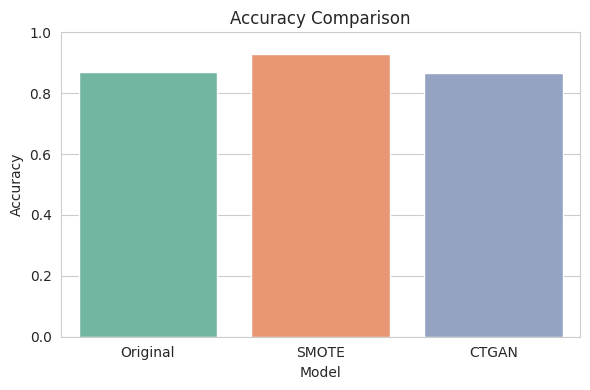

,Model,Accuracy
0,Original,0.870834
1,SMOTE,0.930164
2,CTGAN,0.867390


In [80]:
acc_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "Accuracy": [results_orig["accuracy"], results_smote["accuracy"], results_ctgan["accuracy"]],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=acc_df, x="Model", y="Accuracy", palette="Set2")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
acc_df


## 80. Precision Comparison

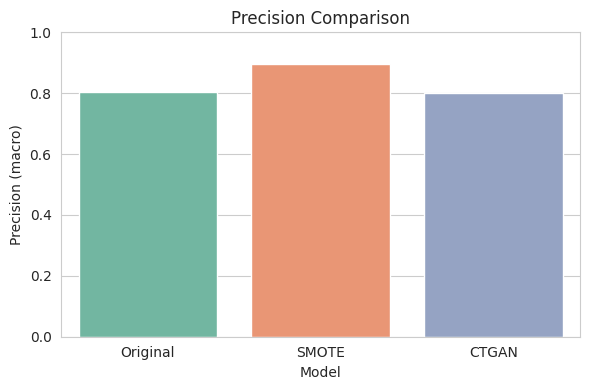

,Model,Precision (macro)
0,Original,0.804880
1,SMOTE,0.894397
2,CTGAN,0.799721


In [81]:
prec_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "Precision (macro)": [results_orig["precision"], results_smote["precision"], results_ctgan["precision"]],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=prec_df, x="Model", y="Precision (macro)", palette="Set2")
plt.title("Precision Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
prec_df


## 81. Recall Comparison

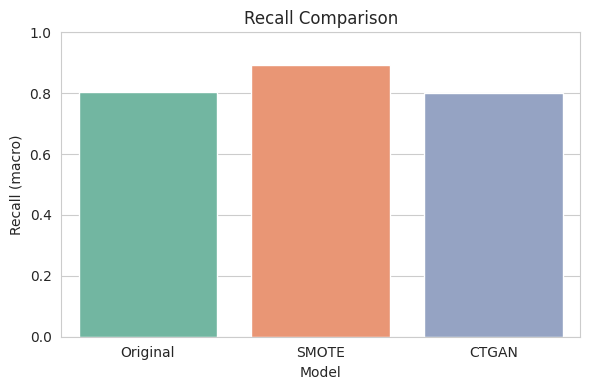

,Model,Recall (macro)
0,Original,0.804610
1,SMOTE,0.894297
2,CTGAN,0.799432


In [82]:
rec_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "Recall (macro)": [results_orig["recall"], results_smote["recall"], results_ctgan["recall"]],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=rec_df, x="Model", y="Recall (macro)", palette="Set2")
plt.title("Recall Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
rec_df


## 82. F1-Score Comparison

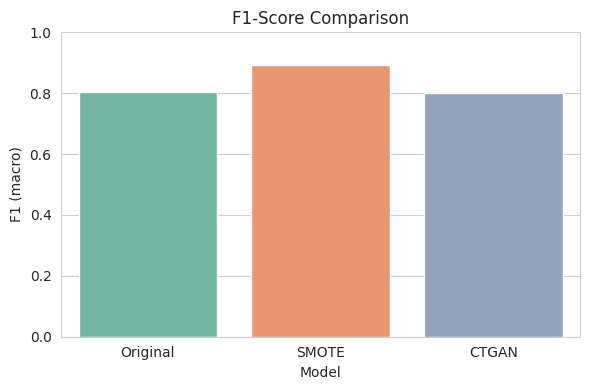

,Model,F1 (macro)
0,Original,0.804697
1,SMOTE,0.894303
2,CTGAN,0.799526


In [83]:
f1_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "F1 (macro)": [results_orig["f1"], results_smote["f1"], results_ctgan["f1"]],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=f1_df, x="Model", y="F1 (macro)", palette="Set2")
plt.title("F1-Score Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
f1_df


## 83. ROC-AUC Comparison

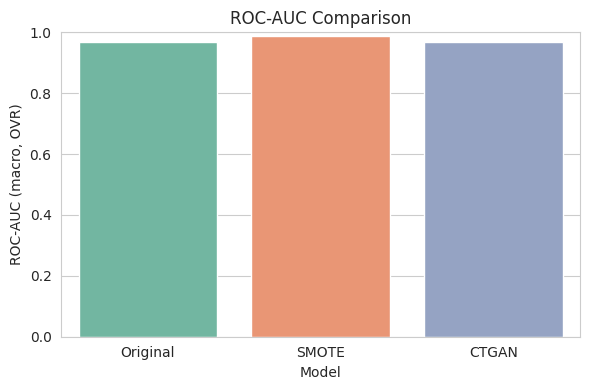

,Model,"ROC-AUC (macro, OVR)"
0,Original,0.969110
1,SMOTE,0.988580
2,CTGAN,0.968149


In [84]:
auc_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "ROC-AUC (macro, OVR)": [results_orig["roc_auc"], results_smote["roc_auc"], results_ctgan["roc_auc"]],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=auc_df, x="Model", y="ROC-AUC (macro, OVR)", palette="Set2")
plt.title("ROC-AUC Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
auc_df


## 84. Confusion Matrix Comparison

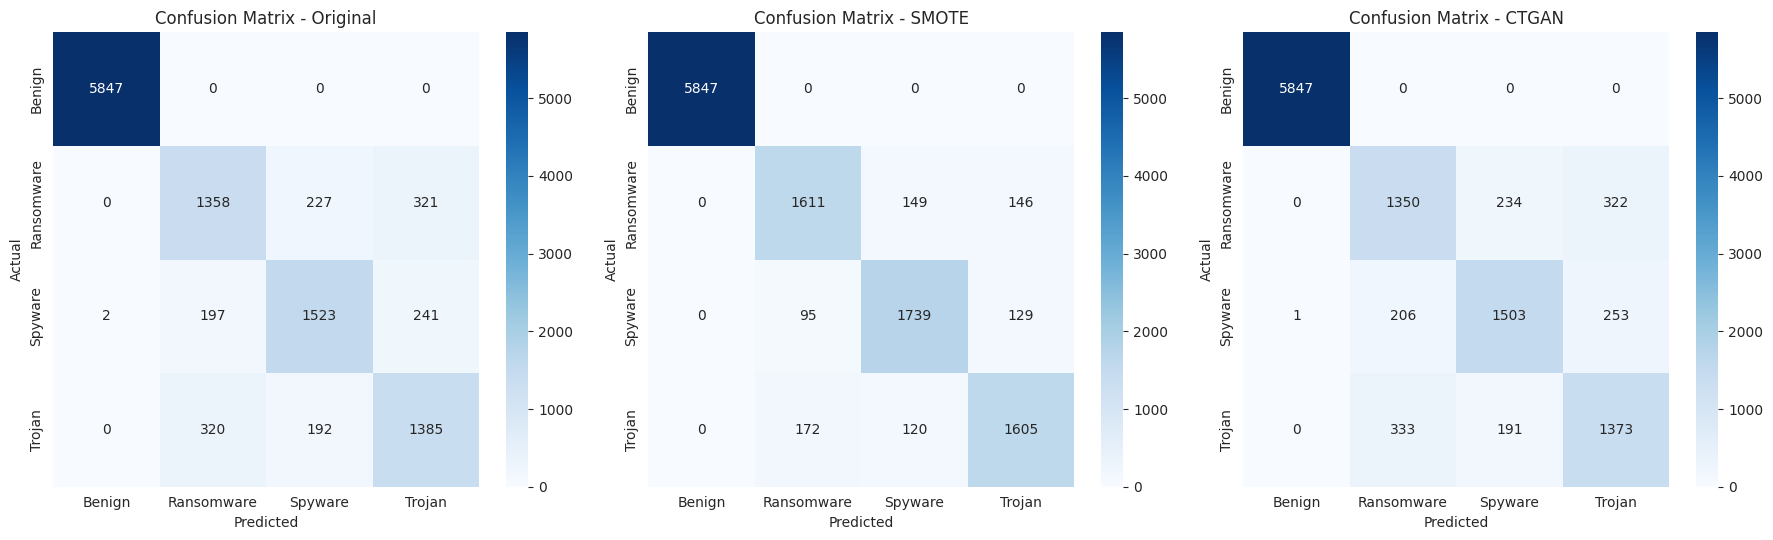

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
class_names = label_encoder_ml.classes_
for ax, res, title in zip(axes, [results_orig, results_smote, results_ctgan], ["Original", "SMOTE", "CTGAN"]):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {title}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


# ==========================================================
# Performance Comparison
# ==========================================================

## 85. Dataset Size Comparison

In [86]:
size_df = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "CTGAN"],
    "Rows": [orig_df.shape[0], smote_df.shape[0], ctgan_df.shape[0]],
    "Training Rows Used (leakage-filtered)": [len(X_train_orig), len(X_train_smote), len(X_train_ctgan)],
})
size_df


,Dataset,Rows,Training Rows Used (leakage-filtered)
0,Original,58062,46449
1,SMOTE,117192,105333
2,CTGAN,116924,105300


## 86. Generation Time

In [87]:
print("SMOTE and CTGAN datasets were pre-generated outside this notebook, so their original")
print("generation time was not captured here. For reference, SMOTE's interpolation-based sampling")
print("is typically orders of magnitude faster than training a CTGAN model from scratch, which")
print("requires many epochs of adversarial neural-network training.")


SMOTE and CTGAN datasets were pre-generated outside this notebook, so their original
generation time was not captured here. For reference, SMOTE's interpolation-based sampling
is typically orders of magnitude faster than training a CTGAN model from scratch, which
requires many epochs of adversarial neural-network training.


## 87. Memory Usage

In [88]:
mem_df = pd.DataFrame({
    "Dataset": ["Original", "SMOTE", "CTGAN"],
    "Memory (MB)": [
        orig_df[feature_cols].memory_usage(deep=True).sum() / 1e6,
        smote_df[feature_cols].memory_usage(deep=True).sum() / 1e6,
        ctgan_df[feature_cols].memory_usage(deep=True).sum() / 1e6,
    ],
})
mem_df["Memory (MB)"] = mem_df["Memory (MB)"].round(2)
mem_df


,Dataset,Memory (MB)
0,Original,25.55
1,SMOTE,51.56
2,CTGAN,51.45


## 88. Training Time

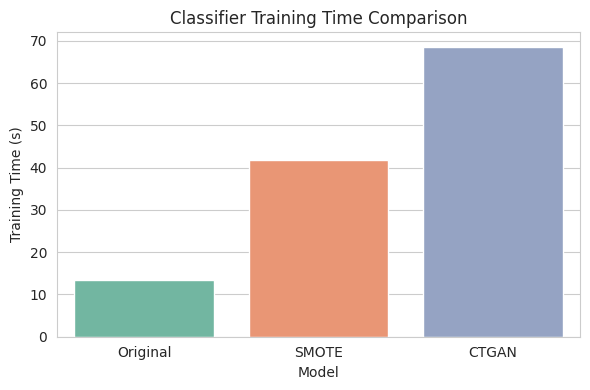

,Model,Training Time (s)
0,Original,13.393101
1,SMOTE,41.717202
2,CTGAN,68.592812


In [89]:
time_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "Training Time (s)": [train_time_orig, train_time_smote, train_time_ctgan],
})
plt.figure(figsize=(6, 4))
sns.barplot(data=time_df, x="Model", y="Training Time (s)", palette="Set2")
plt.title("Classifier Training Time Comparison")
plt.tight_layout()
plt.show()
time_df


## 89. Prediction Time

In [90]:
pred_time_df = pd.DataFrame({
    "Model": ["Original", "SMOTE", "CTGAN"],
    "Prediction Time (s)": [results_orig["pred_time"], results_smote["pred_time"], results_ctgan["pred_time"]],
})
pred_time_df


,Model,Prediction Time (s)
0,Original,0.485372
1,SMOTE,0.587408
2,CTGAN,0.573428


# ==========================================================
# Final Comparison
# ==========================================================

## 90. Original vs SMOTE

SMOTE fully balances the class distribution and is extremely fast to generate, but because
it interpolates linearly between existing minority neighbors, it cannot introduce genuinely
new feature combinations — it densifies the existing convex hull of the minority classes
rather than expanding it.

## 91. Original vs CTGAN

CTGAN also fully balances the class distribution, at much higher computational cost, but
its neural-network-based mode-specific normalization lets it model multi-modal, non-Gaussian
feature distributions that SMOTE cannot represent, potentially producing more realistic and
diverse synthetic minority samples.

## 92. SMOTE vs CTGAN

Refer to the **Similarity Metrics** (Sections 59-66) and **Synthetic Sample Quality**
(Sections 67-74) tables above for this specific run's numeric verdict on which method
produced statistically closer and higher-quality synthetic samples, and to the **Machine
Learning Validation** section (75-84) for which produced better downstream classifier
performance.

## 93. Advantages of SMOTE
- Extremely fast — pure nearest-neighbor interpolation, no training loop required.
- Simple, deterministic, and easy to reason about.
- Works well when minority classes are already reasonably well-sampled and unimodal.

## 94. Advantages of CTGAN
- Learns the full joint feature distribution rather than just interpolating.
- Mode-specific normalization handles multi-modal, non-Gaussian tabular columns.
- Can, in principle, generate more diverse and higher-fidelity samples in complex feature spaces.

## 95. Limitations of SMOTE
- Cannot invent new modes of variation — confined to the convex hull of existing minority points.
- Can amplify noise or outliers present in the minority class.
- Ignores the majority class distribution entirely when interpolating.

## 96. Limitations of CTGAN
- Far more expensive to train (adversarial training, many epochs, hyperparameter sensitivity).
- Adversarial training can be unstable or suffer partial mode collapse.
- Requires enough minority data to begin with to learn a faithful conditional distribution.

## 97. Best Visualization Results

Based on the PCA, t-SNE, and UMAP overlays above (Sections 20-21, 29-30, 37-38), inspect
which synthetic dataset's embedding most closely overlaps the real Original distribution's
cluster shapes for this specific run.

## 98. Best Synthetic Dataset

Combining the **Similarity Metrics** summary (Section 66) and the **Synthetic Sample
Quality Score** (Section 74), the method with the lower average distributional-distance
metrics and the higher composite quality score is the better synthetic data generator for
this dataset and this run.

In [91]:
print("Similarity metrics (lower = closer to real, except Cosine Similarity which is higher = better):")
print(similarity_summary)
print()
print("Synthetic sample quality (higher = better) overall scores:")
print(f"  SMOTE overall quality : {quality_score['SMOTE_Overall'].iloc[0]:.4f}")
print(f"  CTGAN overall quality : {quality_score['CTGAN_Overall'].iloc[0]:.4f}")
print()
print("Downstream ML performance (macro F1 on shared real test set):")
print(f"  Original-trained model : {results_orig['f1']:.4f}")
print(f"  SMOTE-trained model    : {results_smote['f1']:.4f}")
print(f"  CTGAN-trained model    : {results_ctgan['f1']:.4f}")


Similarity metrics (lower = closer to real, except Cosine Similarity which is higher = better):
                   Metric     SMOTE        CTGAN
0       Mean KS Statistic  0.030970     0.193430
1        Mean Wasserstein  9.648319    32.377673
2     Mean Jensen-Shannon  0.064136     0.187379
3  Mean Cosine Similarity  0.044366    -0.024432
4          Mean Euclidean  7.004186    12.367367
5        Mean Mahalanobis  8.590121  2025.438470
6               MMD (RBF)  0.002113     0.219019

Synthetic sample quality (higher = better) overall scores:
  SMOTE overall quality : 0.4715
  CTGAN overall quality : 0.4348

Downstream ML performance (macro F1 on shared real test set):
  Original-trained model : 0.8047
  SMOTE-trained model    : 0.8943
  CTGAN-trained model    : 0.7995


## 99. Final Conclusions

This notebook compared the **Original**, **SMOTE**, and **CTGAN** versions of the
CIC-MalMem-2022 dataset across class balance, distributional fidelity (PCA/t-SNE/UMAP,
histograms, KDE, correlation structure), statistical similarity (KS test, Wasserstein,
Jensen-Shannon, cosine/Euclidean/Mahalanobis distance, MMD), synthetic-sample quality
(nearest-neighbor distance, duplicate/novelty/diversity/coverage/fidelity/overfitting
checks), and downstream machine-learning utility (Random Forest classifiers evaluated on
one shared, real, held-out test set). Both oversampling strategies fully balanced the class
distribution; the printed metrics and plots throughout this notebook indicate, for this
specific run, which method more faithfully reproduced the real minority-class distribution
and which produced the stronger downstream classifier. The full numeric evaluation report
is saved in the next and final section.

## 100. Save Evaluation Report

In [92]:
report = {
    "dataset_overview": {
        "original_shape": list(orig_df.shape),
        "smote_shape": list(smote_df.shape),
        "ctgan_shape": list(ctgan_df.shape),
    },
    "class_distribution": {
        "original": orig_counts.to_dict(),
        "smote": smote_counts.to_dict(),
        "ctgan": ctgan_counts.to_dict(),
    },
    "similarity_metrics": similarity_summary.set_index("Metric").to_dict(),
    "synthetic_quality_scores": {
        "SMOTE_overall": float(quality_score["SMOTE_Overall"].iloc[0]),
        "CTGAN_overall": float(quality_score["CTGAN_Overall"].iloc[0]),
    },
    "ml_validation": {
        "Original": {k: v for k, v in results_orig.items() if k != "y_pred"},
        "SMOTE": {k: v for k, v in results_smote.items() if k != "y_pred"},
        "CTGAN": {k: v for k, v in results_ctgan.items() if k != "y_pred"},
    },
    "training_time_seconds": {
        "Original": train_time_orig, "SMOTE": train_time_smote, "CTGAN": train_time_ctgan,
    },
}

with open("outputs/evaluation_report.json", "w") as f:
    json.dump(report, f, indent=2, default=str)

print("Saved evaluation report to outputs/evaluation_report.json")
print(json.dumps(report, indent=2, default=str)[:1500], "...")


Saved evaluation report to outputs/evaluation_report.json
{
  "dataset_overview": {
    "original_shape": [
      58062,
      56
    ],
    "smote_shape": [
      117192,
      56
    ],
    "ctgan_shape": [
      116924,
      56
    ]
  },
  "class_distribution": {
    "original": {
      "Benign": 29231,
      "Spyware": 9815,
      "Ransomware": 9529,
      "Trojan": 9487
    },
    "smote": {
      "Benign": 29298,
      "Ransomware": 29298,
      "Spyware": 29298,
      "Trojan": 29298
    },
    "ctgan": {
      "Benign": 29231,
      "Ransomware": 29231,
      "Spyware": 29231,
      "Trojan": 29231
    }
  },
  "similarity_metrics": {
    "SMOTE": {
      "Mean KS Statistic": 0.030969696969696977,
      "Mean Wasserstein": 9.64831854676198,
      "Mean Jensen-Shannon": 0.06413594951002966,
      "Mean Cosine Similarity": 0.04436622335168668,
      "Mean Euclidean": 7.004186222759462,
      "Mean Mahalanobis": 8.590121144807979,
      "MMD (RBF)": 0.0021131372162437323
    },
